<a href="https://colab.research.google.com/github/michellejeanmunira/perineal-tear/blob/tear/predict_tear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency, ttest_ind
import statsmodels.api as sm

mounting the drive and loading the dataset

In [32]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/diabetes/deliveries_data_two.csv'
df = pd.read_csv(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   weight_kg  height_cm  BMI  Hemoglobin_level  Pulse_rate  Respiratory_rate  \
0       69.0        160  0.0               0.0          94                20   
1       61.0        167  0.0               0.0          88                16   
2       60.0        167  0.0              12.5          84                20   
3       60.0        160  0.0               0.0          74                18   
4       63.0        161  0.0               0.0          81                19   

   Temperature  blood_pressure_systolic  blood_pressure_diastolic  \
0         36.2                      124                        76   
1         36.8                      110                        70   
2         36.8                      110                        76   
3         36.8                      109                        68   
4         36.4                      117      

data inspection

In [33]:
df.shape

(216, 42)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   weight_kg                        216 non-null    float64
 1   height_cm                        216 non-null    int64  
 2   BMI                              216 non-null    float64
 3   Hemoglobin_level                 216 non-null    float64
 4   Pulse_rate                       216 non-null    int64  
 5   Respiratory_rate                 216 non-null    int64  
 6   Temperature                      216 non-null    float64
 7   blood_pressure_systolic          216 non-null    int64  
 8   blood_pressure_diastolic         216 non-null    int64  
 9   Blood_glucose                    216 non-null    int64  
 10  urine_protein                    216 non-null    int64  
 11  urine_sugar                      216 non-null    int64  
 12  Oxygen_saturation     

In [35]:
df.describe()

,weight_kg,height_cm,BMI,Hemoglobin_level,Pulse_rate,Respiratory_rate,Temperature,blood_pressure_systolic,blood_pressure_diastolic,Blood_glucose,...,duration_of_contractions,Cervical_dialation,Cervical_effacement,Amniotic_fluid_volume,First_stage_of_labour_duration,Second_stage_of_labour_duration,Third_stage_of_labour_duration,Forth_stage_of_labour_duration,NICU_stay,Hosptial_stay
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,...,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.00000,216.000000,216.000000,216.000000
mean,68.439352,161.699074,0.124074,5.806713,85.601852,19.143519,36.830093,117.037037,77.898148,0.939815,...,23.509259,5.709722,54.611111,6.108796,666.254630,47.814815,19.12037,30.574074,2.087963,7.768519
std,9.333385,11.944725,1.823509,6.149216,55.806966,4.014248,1.849845,8.856926,44.647235,9.778528,...,8.285033,1.879992,29.241682,2.579610,257.505575,187.670327,56.03217,162.786132,0.559604,0.916073
min,11.000000,0.000000,0.000000,0.000000,60.000000,0.000000,34.900000,98.000000,52.000000,0.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,3.00000,0.000000,0.000000,1.000000
25%,63.000000,160.000000,0.000000,0.000000,73.000000,18.000000,36.500000,110.000000,70.000000,0.000000,...,18.000000,5.000000,40.000000,5.000000,540.000000,18.000000,8.00000,0.000000,2.000000,8.000000
50%,68.000000,162.000000,0.000000,0.000000,80.500000,19.000000,36.800000,117.500000,74.000000,0.000000,...,20.000000,6.000000,50.000000,6.000000,660.000000,30.000000,10.00000,0.000000,2.000000,8.000000
75%,73.050000,166.000000,0.000000,12.075000,88.000000,20.000000,36.900000,121.000000,80.000000,0.000000,...,30.000000,6.000000,65.000000,8.000000,810.000000,36.000000,15.00000,0.000000,2.000000,8.000000
max,99.500000,171.000000,26.800000,16.300000,886.000000,60.000000,63.400000,149.000000,720.000000,110.000000,...,50.000000,15.000000,400.000000,18.000000,1540.000000,2280.000000,642.00000,1140.000000,3.000000,10.000000


In [36]:
df.isnull().sum()

,0
weight_kg,0
height_cm,0
BMI,0
Hemoglobin_level,0
Pulse_rate,0
Respiratory_rate,0
Temperature,0
blood_pressure_systolic,0
blood_pressure_diastolic,0
Blood_glucose,0


In [37]:
df.duplicated().sum()

np.int64(0)

heat map

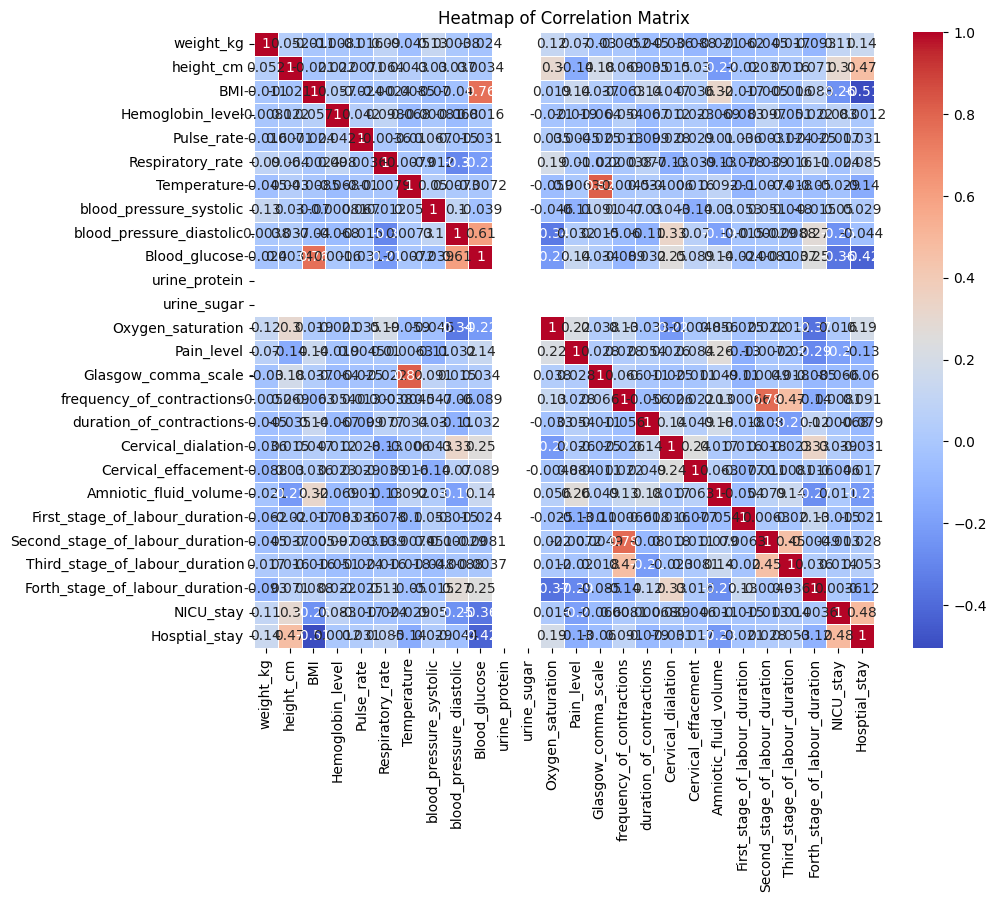

In [38]:

numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of Correlation Matrix')
plt.show()

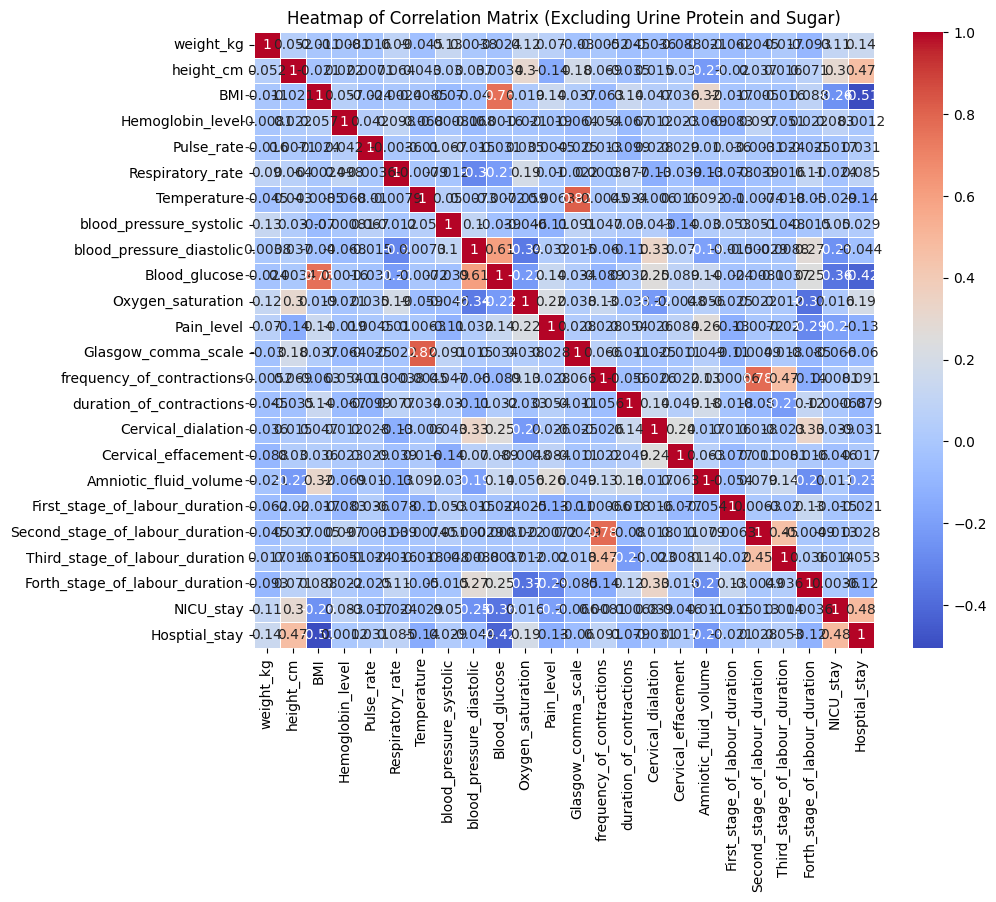

In [39]:

numeric_df = df.select_dtypes(include=['number'])

# Drop 'urine_protein' and 'urine_sugar' columns
numeric_df = numeric_df.drop(['urine_protein', 'urine_sugar'], axis=1)
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of Correlation Matrix (Excluding Urine Protein and Sugar)')
plt.show()


other visualizations

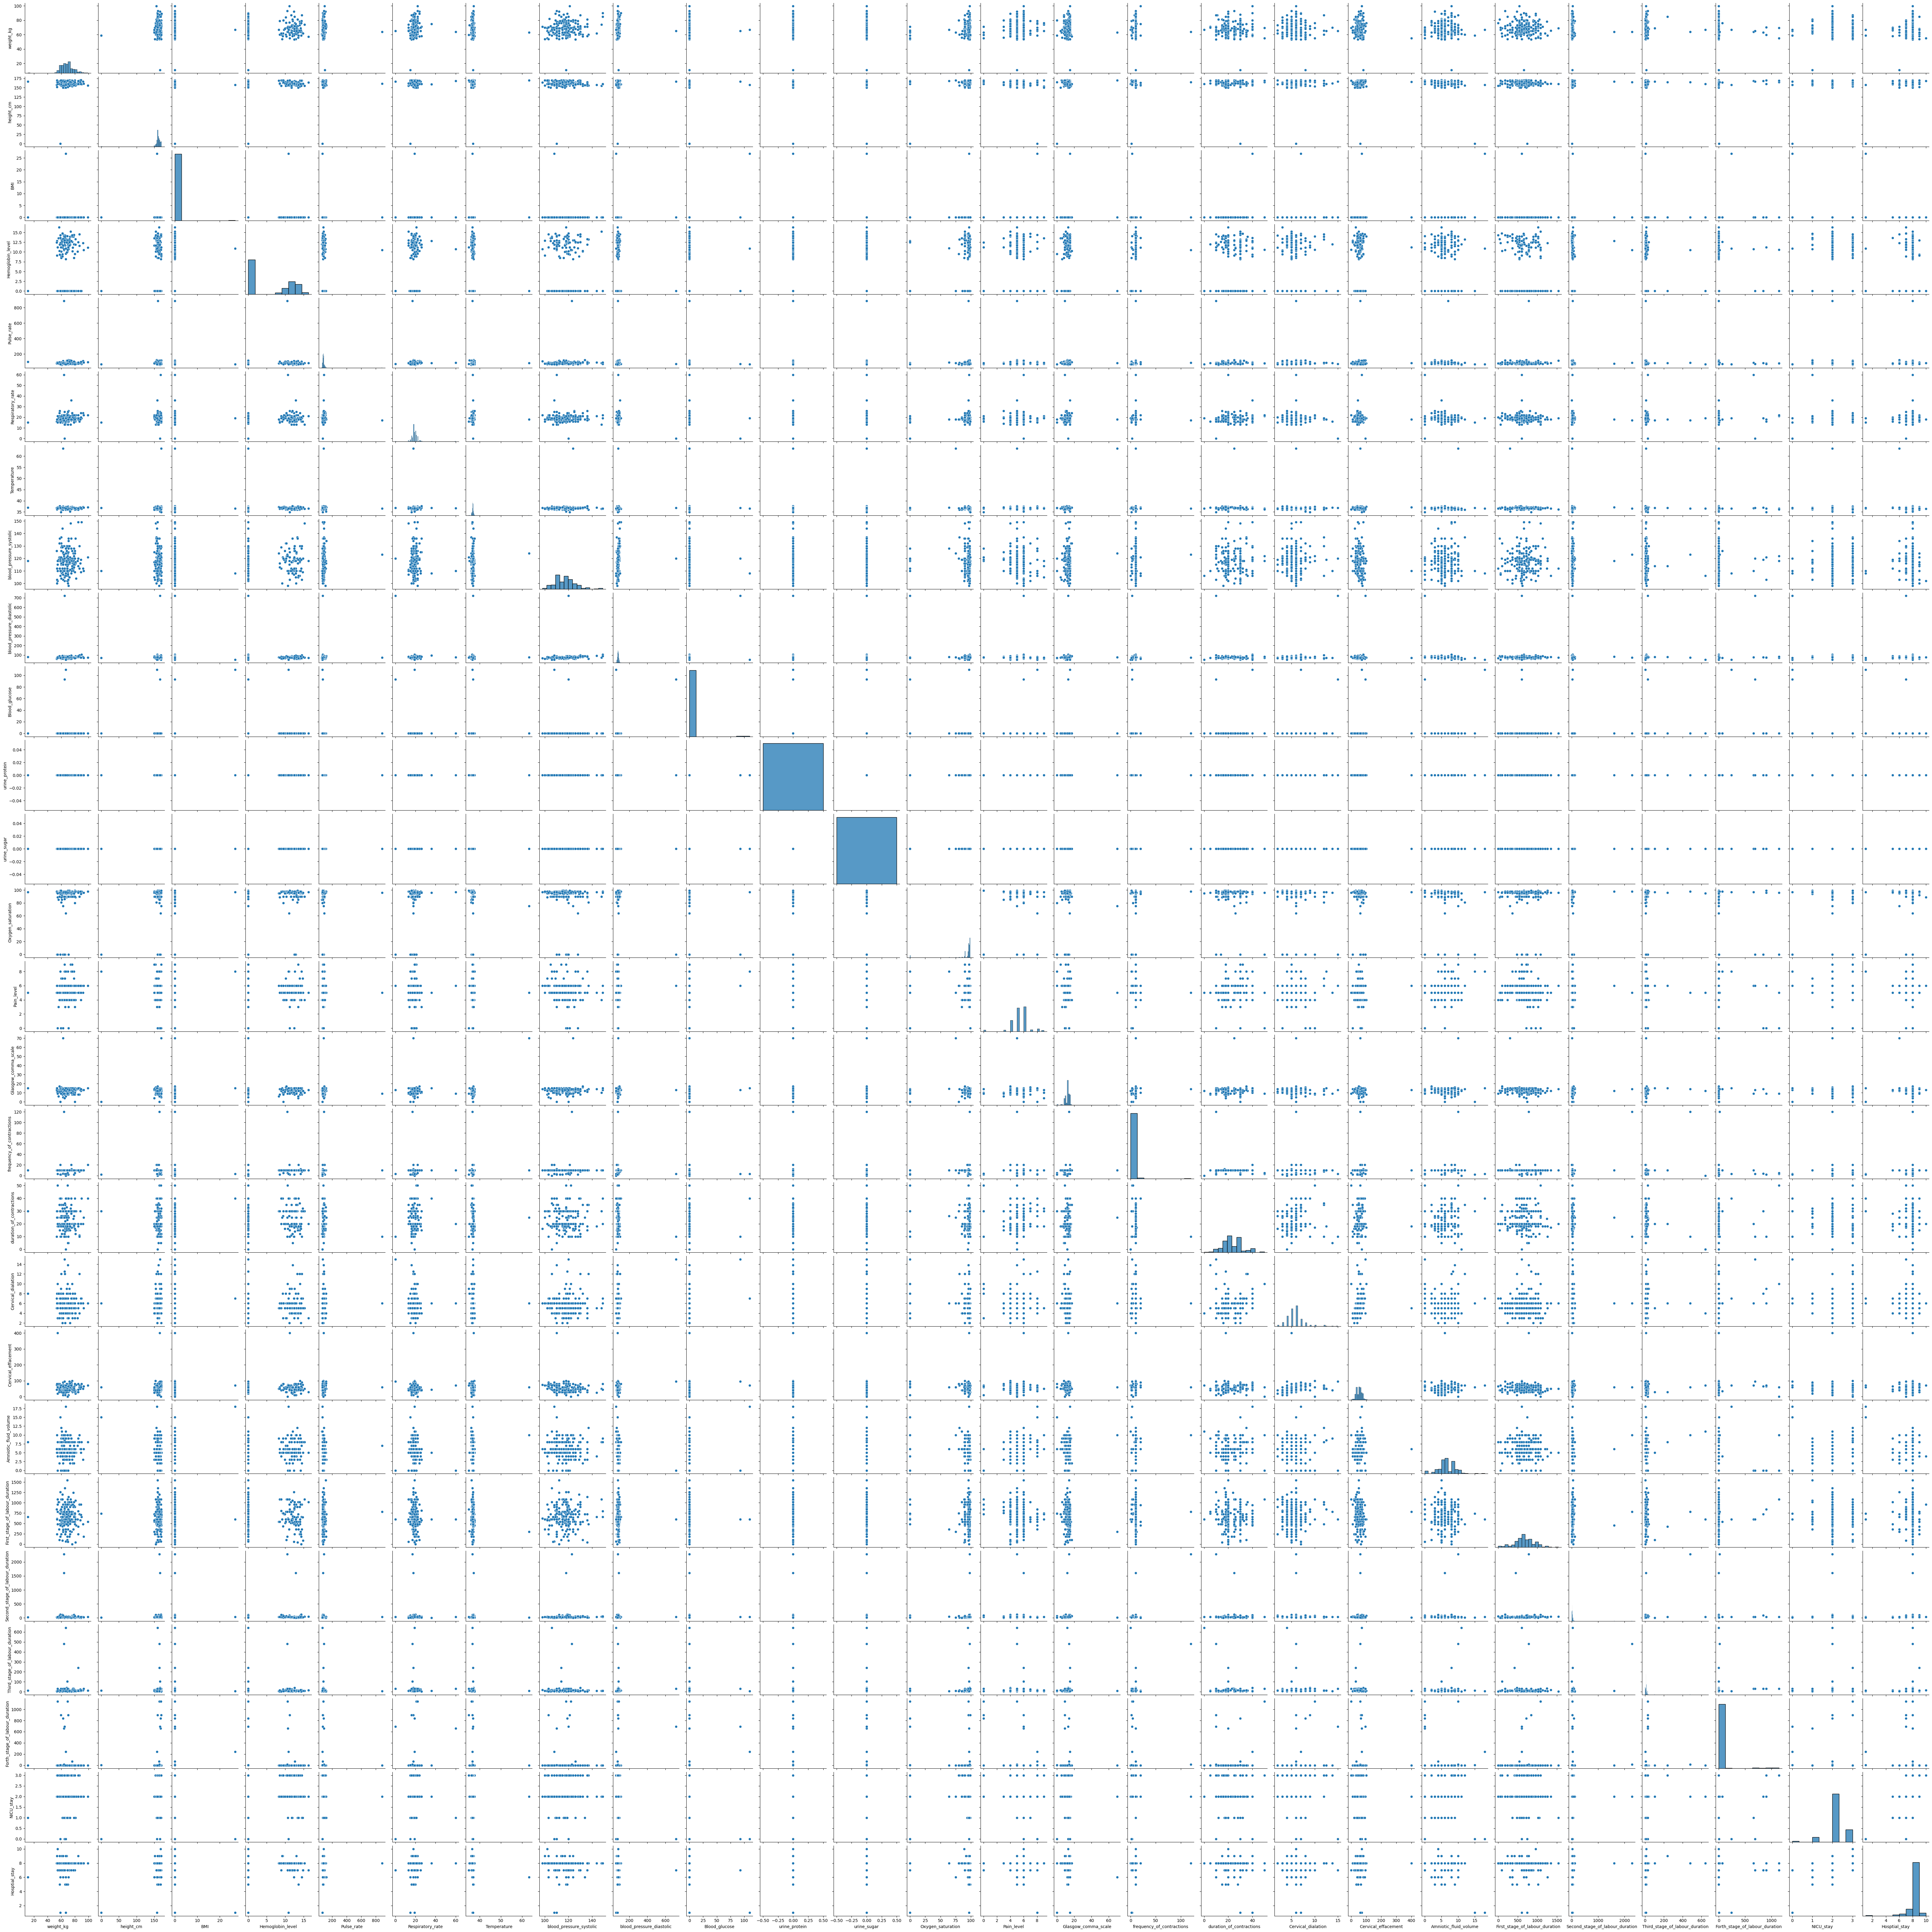

In [40]:
sns.pairplot(df)
plt.show()

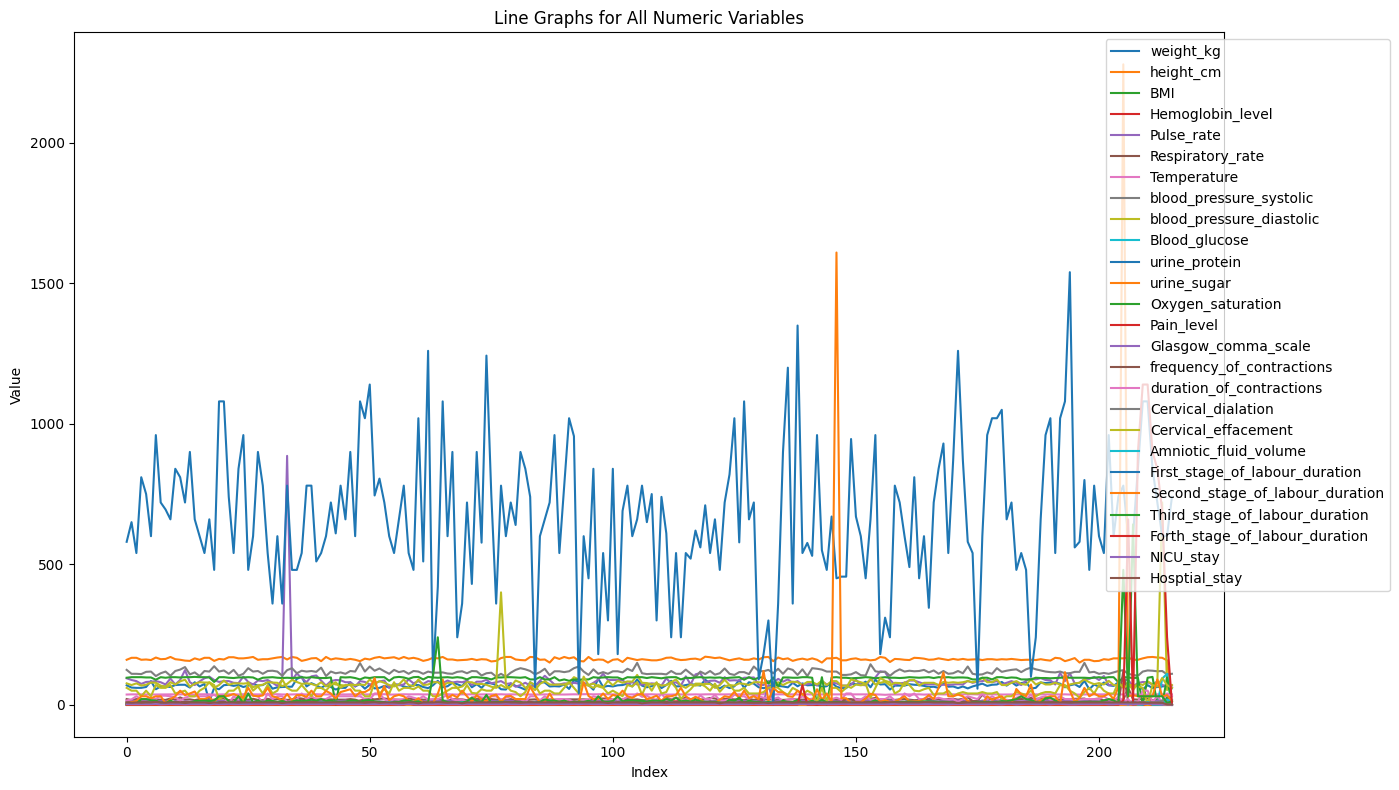

In [41]:

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(14, 8))

for column in numeric_df.columns:
    plt.plot(numeric_df[column], label=column)

plt.title('Line Graphs for All Numeric Variables')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))
plt.tight_layout()
plt.show()


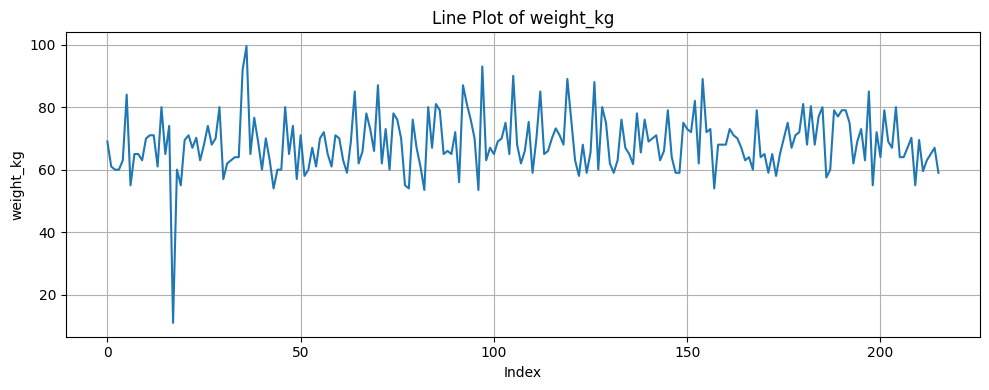

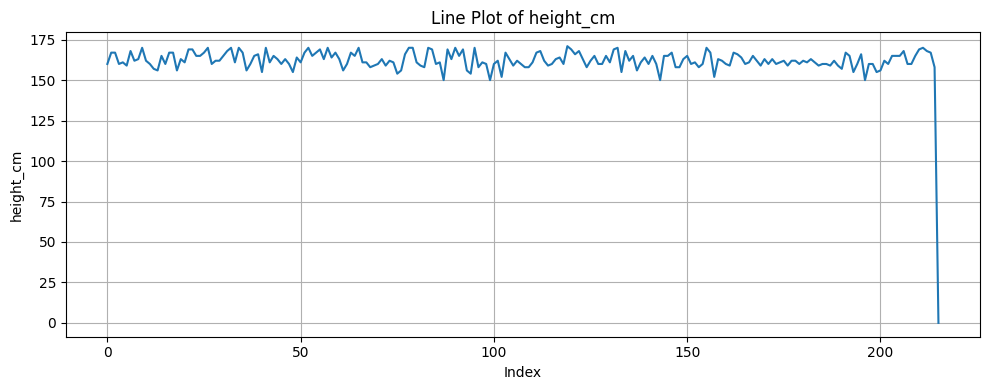

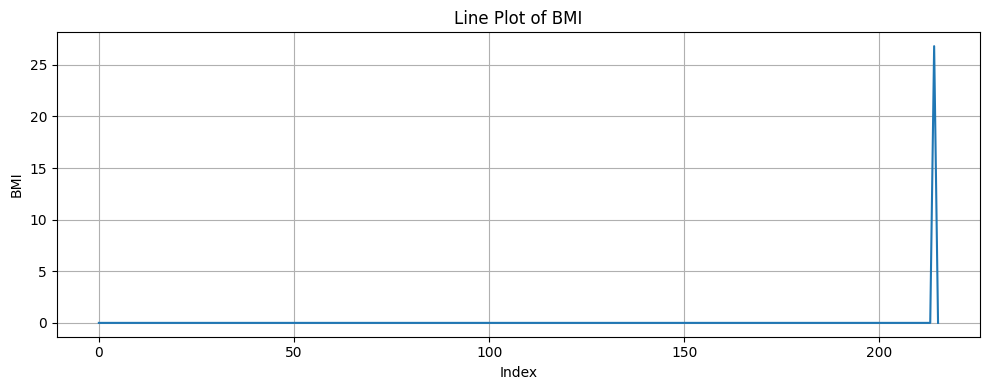

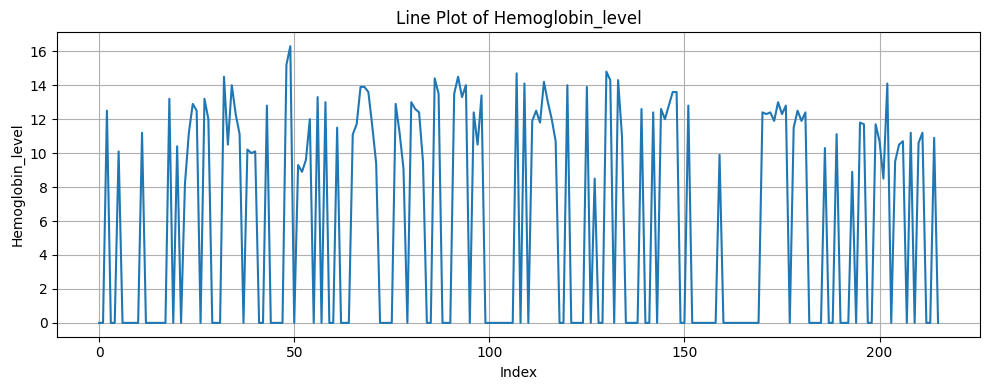

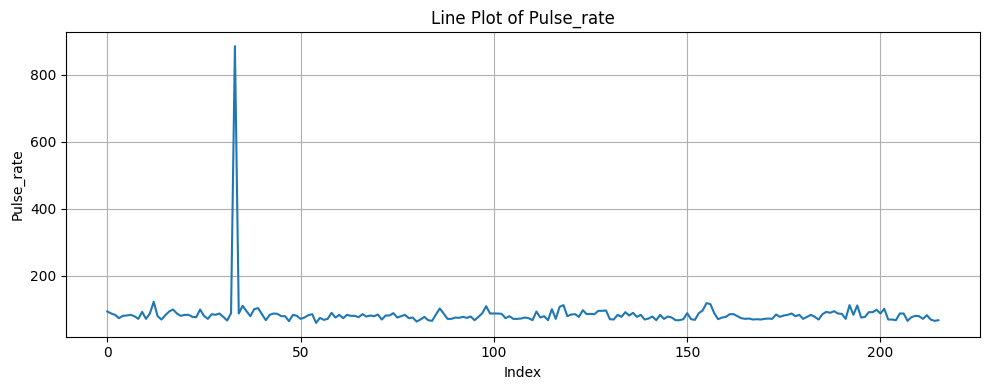

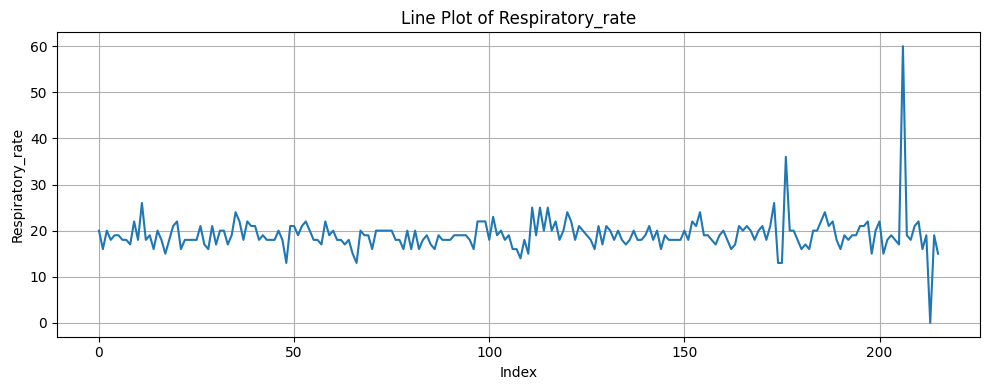

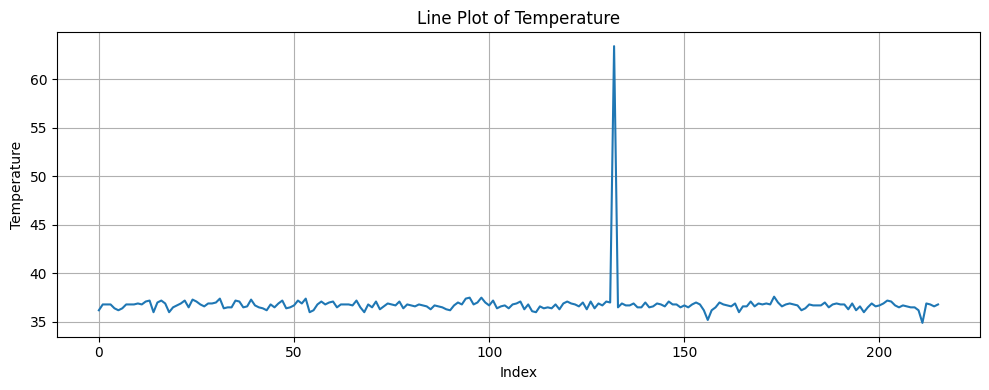

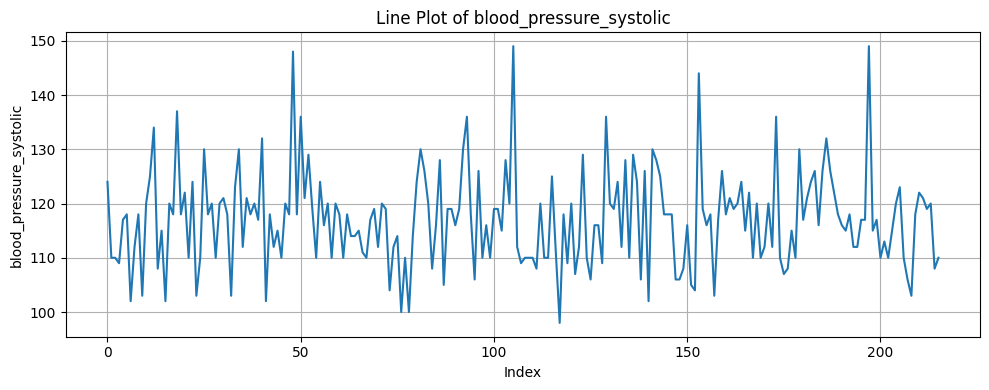

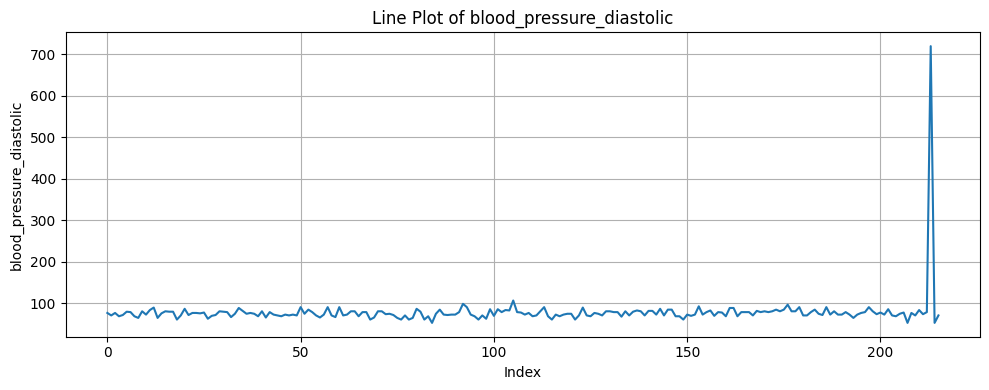

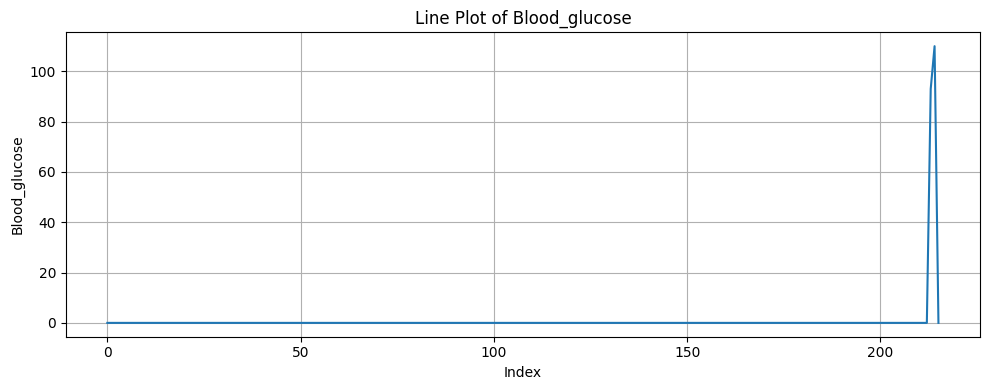

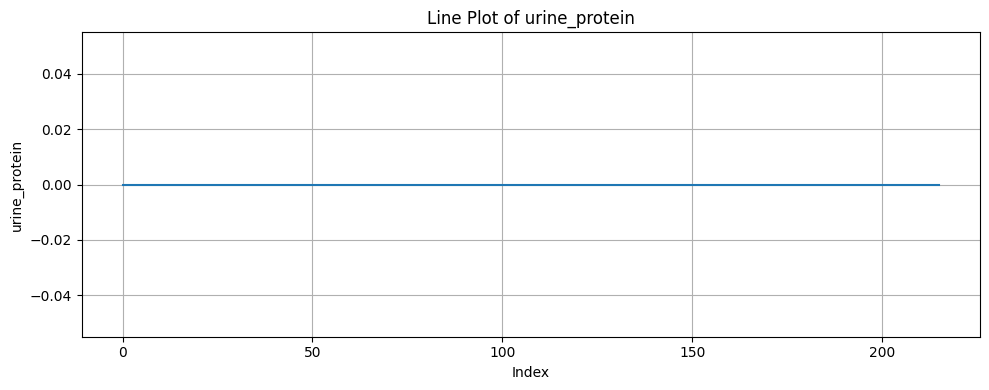

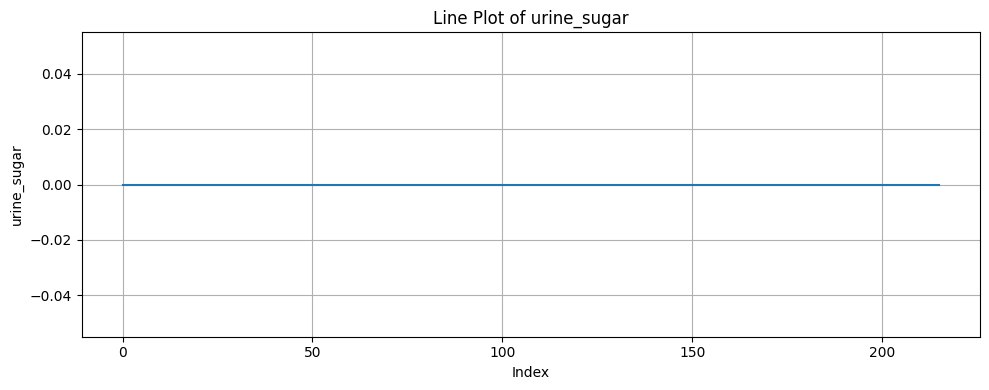

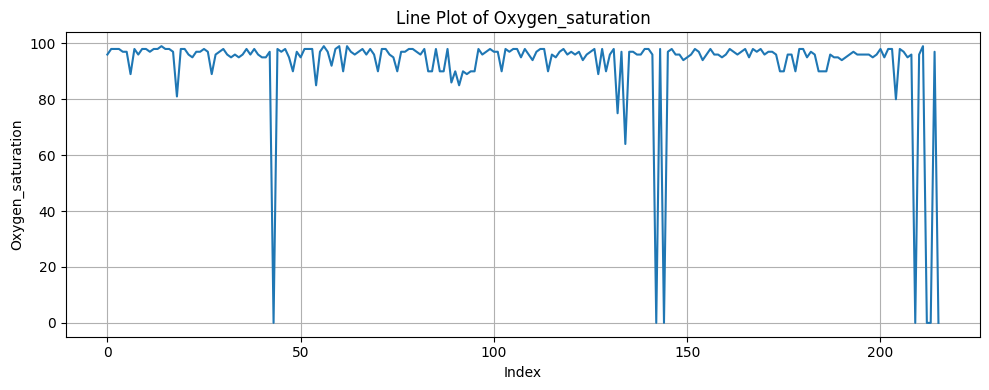

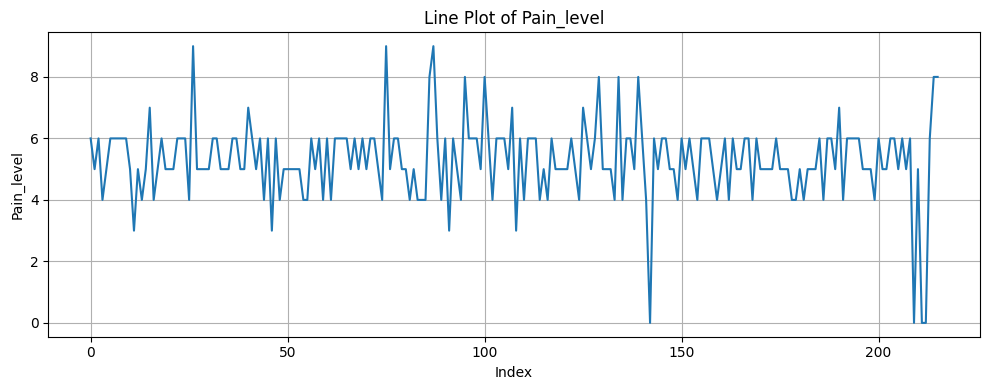

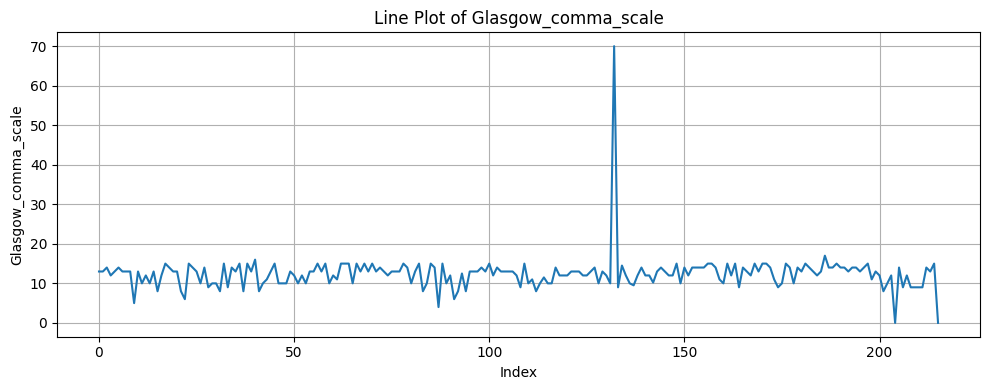

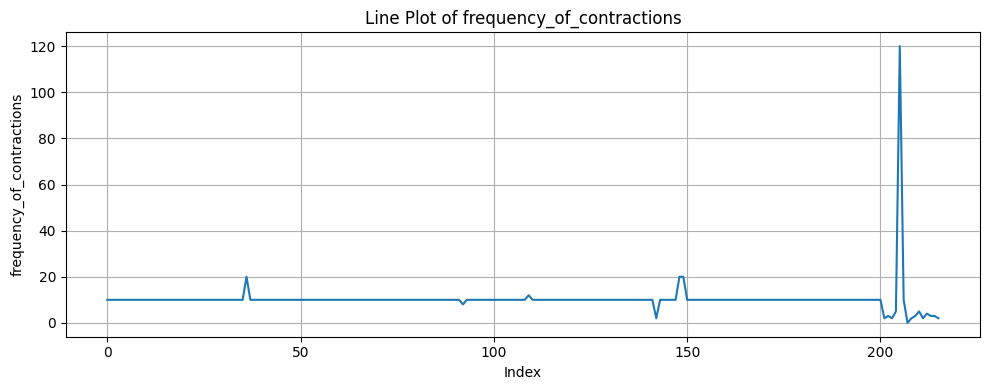

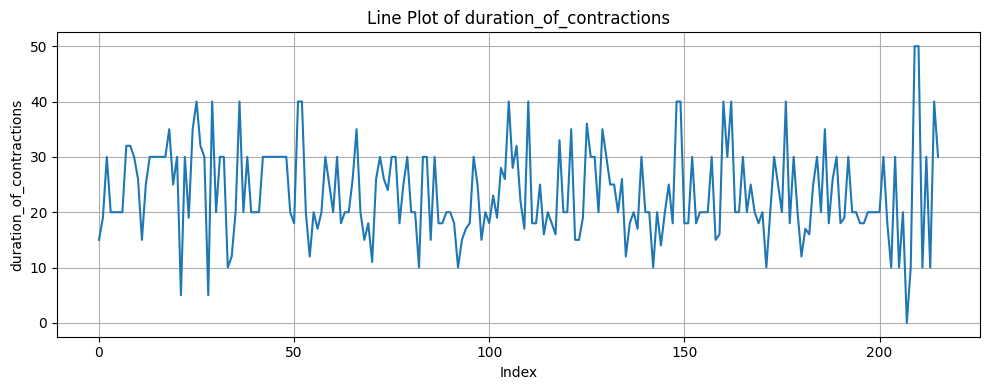

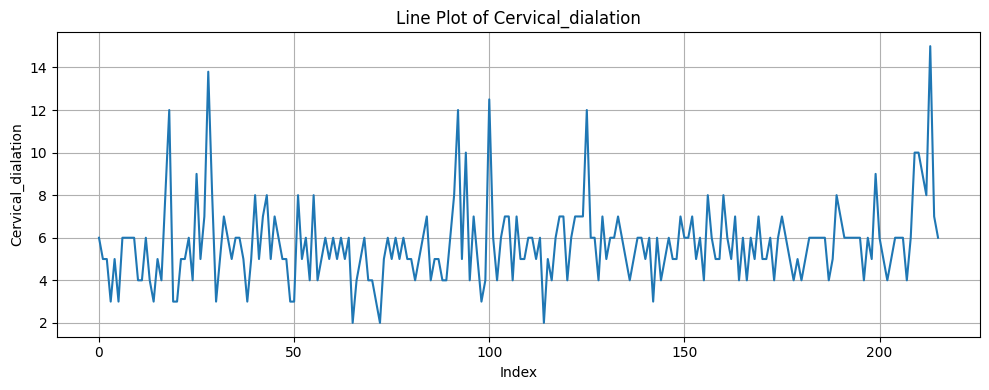

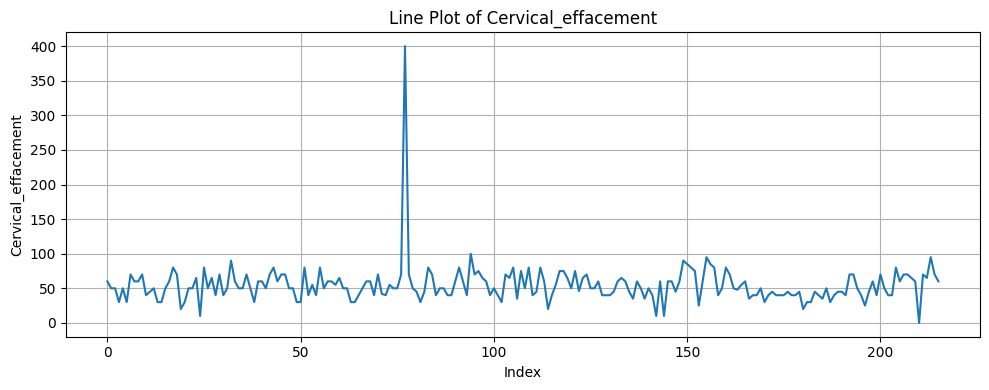

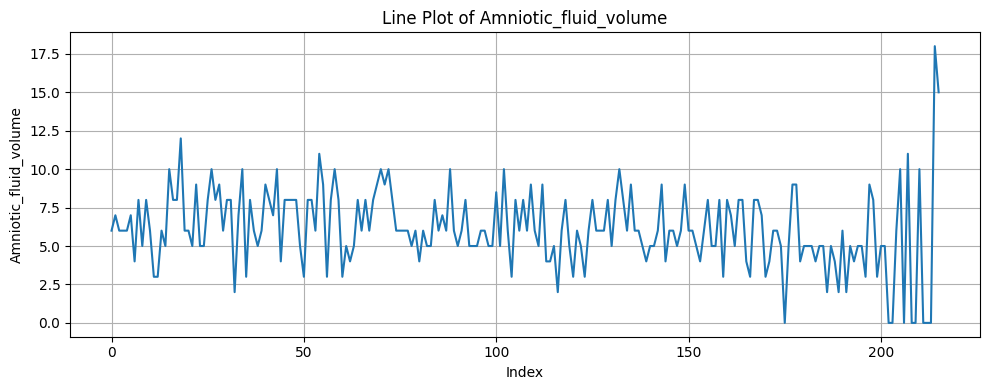

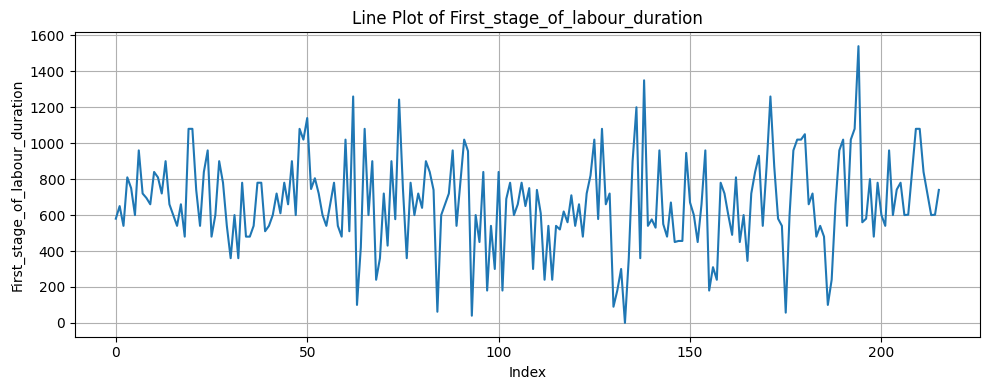

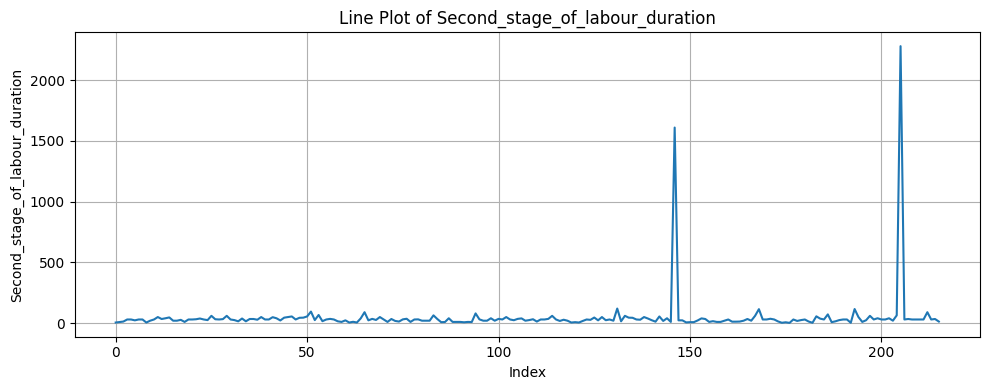

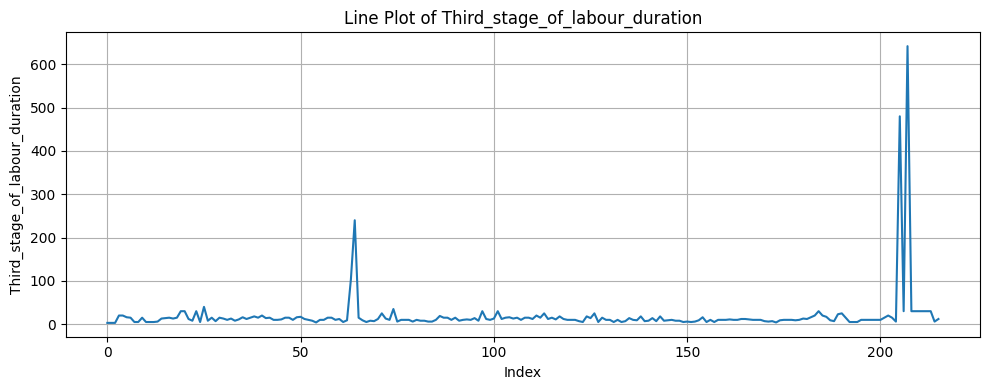

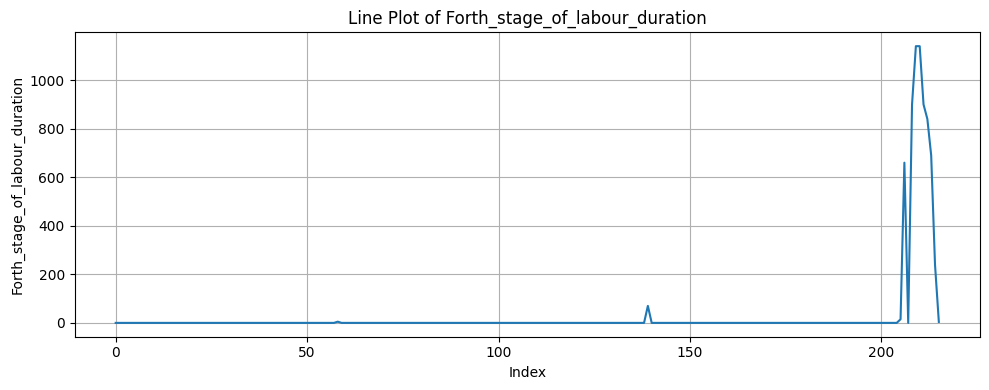

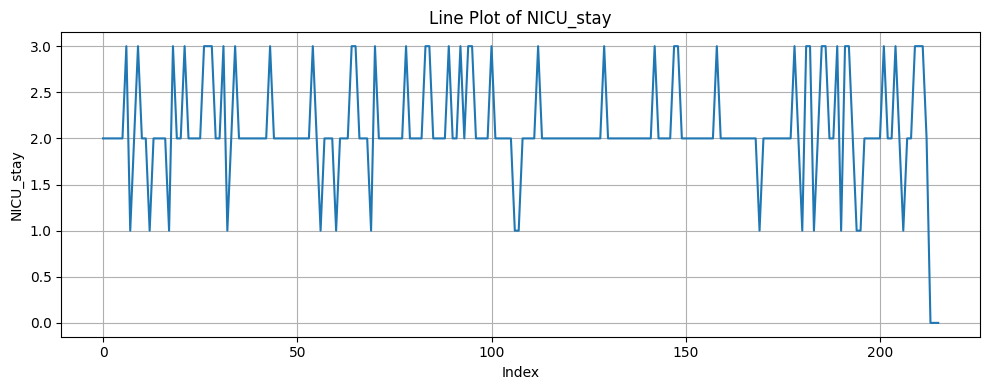

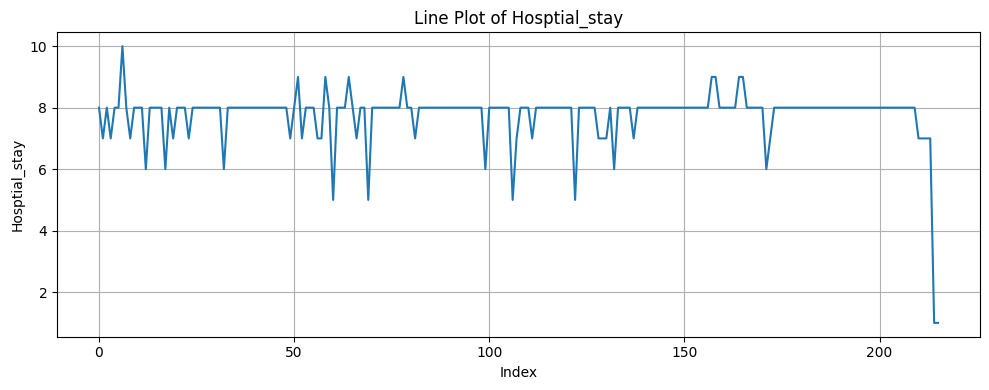

In [42]:

for column in numeric_df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(numeric_df[column])
    plt.title(f'Line Plot of {column}')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [43]:
print(df.columns)


Index(['weight_kg', 'height_cm', 'BMI', 'Hemoglobin_level', 'Pulse_rate',
       'Respiratory_rate', 'Temperature', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'Blood_glucose', 'urine_protein',
       'urine_sugar', 'Oxygen_saturation', 'Pain_level', 'Glasgow_comma_scale',
       'frequency_of_contractions', 'duration_of_contractions',
       'intensity_of_contractions', 'Fetal_heart_rate', 'Cervical_dialation',
       'Cervical_effacement', 'Membrane_status', 'Amniotic_fluid_volume',
       'Maternal_positioning', 'Level_of_consciousness', 'type_of_delivery',
       'Jaundice', 'Induced_labour', 'Episiotomy', 'Perineal_tear',
       'Time_of_rapture', 'Placenta', 'Placenta_delivery', 'Time_of_delivery',
       'Time_of_delivery_of_placenta', 'First_stage_of_labour_duration',
       'Second_stage_of_labour_duration', 'Third_stage_of_labour_duration',
       'Forth_stage_of_labour_duration', 'Full_term', 'NICU_stay',
       'Hosptial_stay'],
      dtype='object')


In [44]:
df['Perineal_tear']


,Perineal_tear
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
211,No
212,No
213,Yes
214,No


bivarate analysis

In [45]:
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency

# Convert dependent variable to categorical if it's not already
df['Perineal_tear'] = df['Perineal_tear'].astype('category')

# Separate numeric and categorical variables
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Remove the dependent variable from independent lists
if 'Perineal_tear' in numeric_vars: numeric_vars.remove('Perineal_tear')
if 'Perineal_tear' in categorical_vars: categorical_vars.remove('Perineal_tear')

print("Bivariate Analysis Results:\n")

# Bivariate analysis with numeric independent variables: T-test
for col in numeric_vars:
    group0 = df[df['Perineal_tear'] == 0][col]
    group1 = df[df['Perineal_tear'] == 1][col]
    stat, p = ttest_ind(group0, group1, nan_policy='omit')
    print(f"T-test for {col} vs Perineal_tear: p-value = {p:.4f}")

# Bivariate analysis with categorical independent variables: Chi-square test
for col in categorical_vars:
    contingency = pd.crosstab(df[col], df['Perineal_tear'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi-square for {col} vs Perineal_tear: p-value = {p:.4f}")


Bivariate Analysis Results:

T-test for weight_kg vs Perineal_tear: p-value = nan
T-test for height_cm vs Perineal_tear: p-value = nan
T-test for BMI vs Perineal_tear: p-value = nan
T-test for Hemoglobin_level vs Perineal_tear: p-value = nan
T-test for Pulse_rate vs Perineal_tear: p-value = nan
T-test for Respiratory_rate vs Perineal_tear: p-value = nan
T-test for Temperature vs Perineal_tear: p-value = nan
T-test for blood_pressure_systolic vs Perineal_tear: p-value = nan
T-test for blood_pressure_diastolic vs Perineal_tear: p-value = nan
T-test for Blood_glucose vs Perineal_tear: p-value = nan
T-test for urine_protein vs Perineal_tear: p-value = nan
T-test for urine_sugar vs Perineal_tear: p-value = nan
T-test for Oxygen_saturation vs Perineal_tear: p-value = nan
T-test for Pain_level vs Perineal_tear: p-value = nan
T-test for Glasgow_comma_scale vs Perineal_tear: p-value = nan
T-test for frequency_of_contractions vs Perineal_tear: p-value = nan
T-test for duration_of_contractions vs

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [46]:
import pandas as pd
import statsmodels.api as sm
from patsy import dmatrices

# Make sure target variable is categorical
df['Perineal_tear'] = df['Perineal_tear'].astype('category')

# Define the variables to include based on bivariate p-value < 0.2
vars_to_include = [
    'height_cm',
    'BMI',
    'Hemoglobin_level',
    'Oxygen_saturation',
    'duration_of_contractions',
    'Cervical_effacement',
    'Amniotic_fluid_volume',
    'Hosptial_stay',
    'Induced_labour'
]

# Create formula string
formula = 'Perineal_tear ~ ' + ' + '.join(vars_to_include)

# Create design matrices
y, X = dmatrices(formula, df, return_type='dataframe')

# Convert y to 1D array
y = y.iloc[:, 0]

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

# Print summary
print(result.summary())



         Current function value: 0.567473
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:      Perineal_tear[No]   No. Observations:                  216
Model:                          Logit   Df Residuals:                      206
Method:                           MLE   Df Model:                            9
Date:                Mon, 26 May 2025   Pseudo R-squ.:                 0.09414
Time:                        14:53:55   Log-Likelihood:                -122.57
converged:                      False   LL-Null:                       -135.31
Covariance Type:            nonrobust   LLR p-value:                  0.002485
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   20.4829   1.11e+04      0.002      0.999   -2.18e+04    2.18e+04
Induced_labour[T.Yes]  

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


training ,testing and validating

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
dataset = pd.read_csv(file_path)

# Display the first few rows of the dataset
print(dataset.head())

# Separate features and target variable
X = dataset.drop('Perineal_tear', axis=1)
y = dataset['Perineal_tear']

# Convert categorical variables to numeric using one-hot encoding
X = pd.get_dummies(X)

# Split the data into training (60%), validation (20%), and testing (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Print the shapes of the resulting datasets
print(f'Training set: {X_train_scaled.shape}, {y_train.shape}')
print(f'Validation set: {X_val_scaled.shape}, {y_val.shape}')
print(f'Test set: {X_test_scaled.shape}, {y_test.shape}')


   weight_kg  height_cm  BMI  Hemoglobin_level  Pulse_rate  Respiratory_rate  \
0       69.0        160  0.0               0.0          94                20   
1       61.0        167  0.0               0.0          88                16   
2       60.0        167  0.0              12.5          84                20   
3       60.0        160  0.0               0.0          74                18   
4       63.0        161  0.0               0.0          81                19   

   Temperature  blood_pressure_systolic  blood_pressure_diastolic  \
0         36.2                      124                        76   
1         36.8                      110                        70   
2         36.8                      110                        76   
3         36.8                      109                        68   
4         36.4                      117                        71   

   Blood_glucose  ...  Placenta_delivery  Time_of_delivery  \
0              0  ...             Normal  

MODELS


Training Accuracy: 1.00
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        88

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129



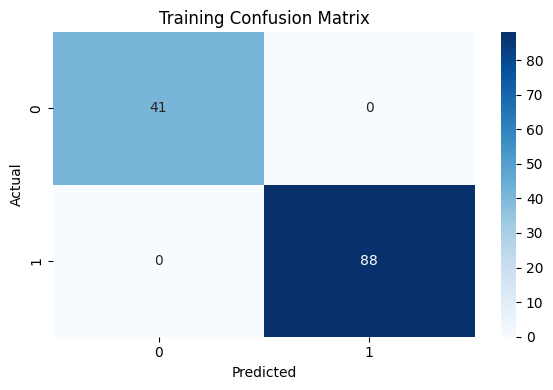


Validation Accuracy: 0.70
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.10      0.13        10
           1       0.76      0.88      0.82        33

    accuracy                           0.70        43
   macro avg       0.48      0.49      0.48        43
weighted avg       0.63      0.70      0.66        43



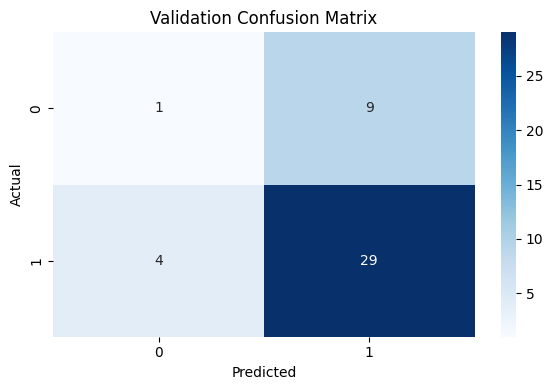


Testing Accuracy: 0.61
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.22      0.32        18
           1       0.62      0.88      0.73        26

    accuracy                           0.61        44
   macro avg       0.60      0.55      0.53        44
weighted avg       0.60      0.61      0.56        44



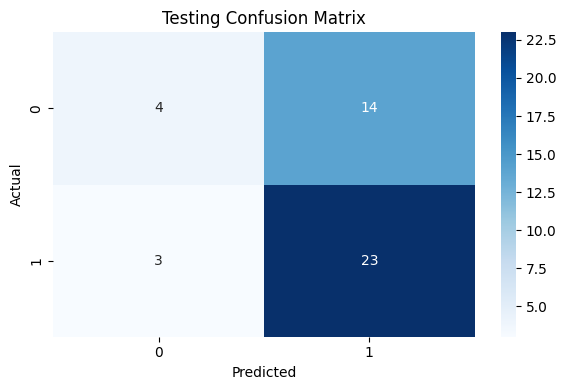

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import RidgeClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
dataset = pd.read_csv(file_path)

# Separate features and target variable
X = dataset.drop('Perineal_tear', axis=1)
y = dataset['Perineal_tear']

# Convert categorical variables to numeric using one-hot encoding
X = pd.get_dummies(X)

# Convert target variable to numeric if it's categorical
if y.dtype == 'object':
    y = y.astype('category').cat.codes

# Split data: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Ridge Classifier
model = RidgeClassifier()
model.fit(X_train_scaled, y_train)

# Function to evaluate and plot
def evaluate_model(X, y, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{dataset_name} Accuracy: {acc:.2f}")
    print(f"{dataset_name} Classification Report:\n{classification_report(y, y_pred)}")

    conf_matrix = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Evaluate on all three sets
evaluate_model(X_train_scaled, y_train, "Training")
evaluate_model(X_val_scaled, y_val, "Validation")
evaluate_model(X_test_scaled, y_test, "Testing")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 88, number of negative: 41
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 129, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.682171 -> initscore=0.763765
[LightGBM] [Info] Start training from score 0.763765
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

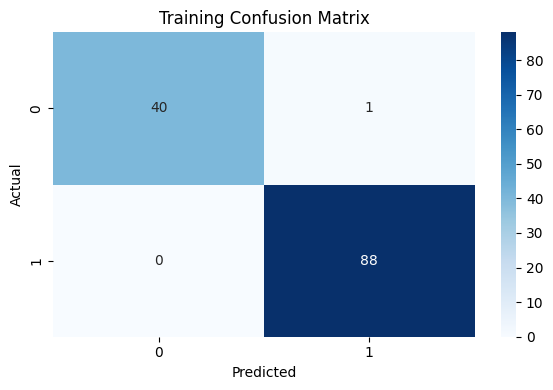


Validation Accuracy: 0.84
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.88      0.91      0.90        33

    accuracy                           0.84        43
   macro avg       0.77      0.75      0.76        43
weighted avg       0.83      0.84      0.83        43



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


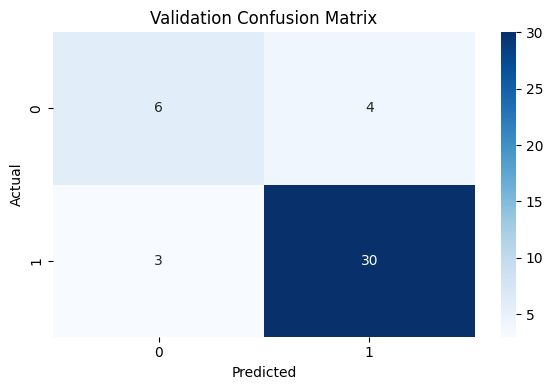

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Testing Accuracy: 0.57
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.11      0.17        18
           1       0.59      0.88      0.71        26

    accuracy                           0.57        44
   macro avg       0.49      0.50      0.44        44
weighted avg       0.51      0.57      0.49        44



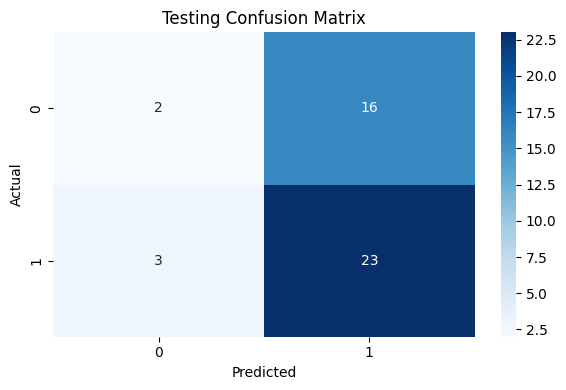

In [49]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
# Split data: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Ridge Classifier
model = LGBMClassifier()
model.fit(X_train_scaled, y_train)

# Function to evaluate and plot
def evaluate_model(X, y, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{dataset_name} Accuracy: {acc:.2f}")
    print(f"{dataset_name} Classification Report:\n{classification_report(y, y_pred)}")

    conf_matrix = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Evaluate on all three sets
evaluate_model(X_train_scaled, y_train, "Training")
evaluate_model(X_val_scaled, y_val, "Validation")
evaluate_model(X_test_scaled, y_test, "Testing")



Training Accuracy: 1.00
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        88

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129



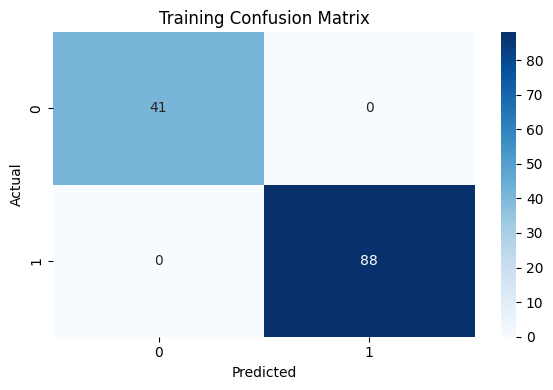


Validation Accuracy: 0.84
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.30      0.46        10
           1       0.82      1.00      0.90        33

    accuracy                           0.84        43
   macro avg       0.91      0.65      0.68        43
weighted avg       0.87      0.84      0.80        43



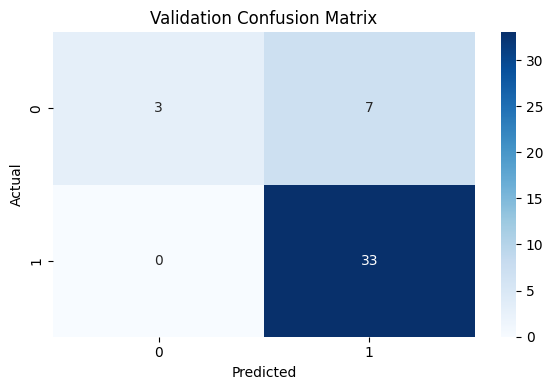


Testing Accuracy: 0.57
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.58      0.96      0.72        26

    accuracy                           0.57        44
   macro avg       0.29      0.48      0.36        44
weighted avg       0.34      0.57      0.43        44



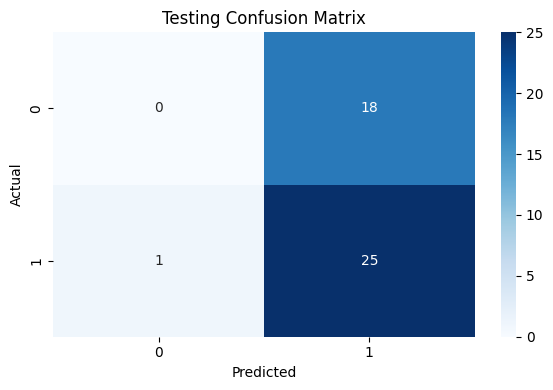

In [50]:
!pip install catboost
from catboost import CatBoostClassifier
model = CatBoostClassifier(verbose=0)
# Split data: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


model.fit(X_train_scaled, y_train)

# Function to evaluate and plot
def evaluate_model(X, y, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{dataset_name} Accuracy: {acc:.2f}")
    print(f"{dataset_name} Classification Report:\n{classification_report(y, y_pred)}")

    conf_matrix = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Evaluate on all three sets
evaluate_model(X_train_scaled, y_train, "Training")
evaluate_model(X_val_scaled, y_val, "Validation")
evaluate_model(X_test_scaled, y_test, "Testing")


Training Accuracy: 0.85
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.54      0.70        41
           1       0.82      1.00      0.90        88

    accuracy                           0.85       129
   macro avg       0.91      0.77      0.80       129
weighted avg       0.88      0.85      0.84       129



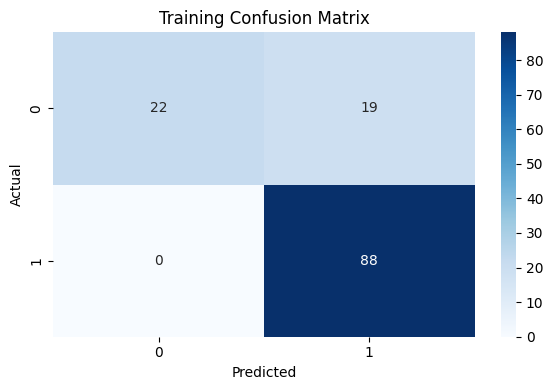


Validation Accuracy: 0.81
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.40      0.50        10
           1       0.84      0.94      0.89        33

    accuracy                           0.81        43
   macro avg       0.75      0.67      0.69        43
weighted avg       0.80      0.81      0.80        43



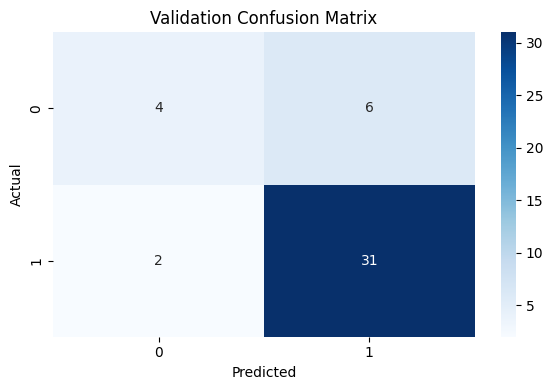


Testing Accuracy: 0.50
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.55      0.85      0.67        26

    accuracy                           0.50        44
   macro avg       0.28      0.42      0.33        44
weighted avg       0.33      0.50      0.39        44



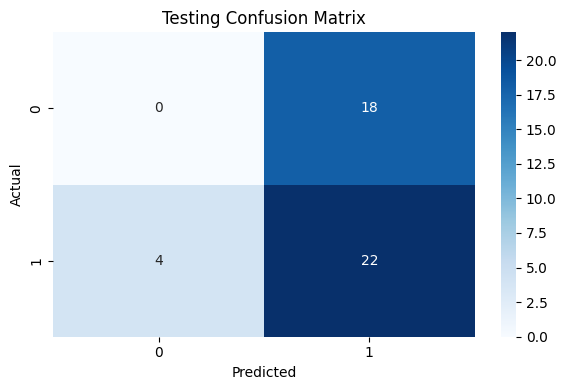

In [51]:

from sklearn.ensemble import AdaBoostClassifier

# Initialize the AdaBoost classifier
model = AdaBoostClassifier()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = AdaBoostClassifier()
model.fit(X_train_scaled, y_train)

# Function to evaluate and plot
def evaluate_model(X, y, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{dataset_name} Accuracy: {acc:.2f}")
    print(f"{dataset_name} Classification Report:\n{classification_report(y, y_pred)}")

    conf_matrix = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Evaluate on all three sets
evaluate_model(X_train_scaled, y_train, "Training")
evaluate_model(X_val_scaled, y_val, "Validation")
evaluate_model(X_test_scaled, y_test, "Testing")


Training Accuracy: 0.74
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.17      0.29        41
           1       0.72      1.00      0.84        88

    accuracy                           0.74       129
   macro avg       0.86      0.59      0.56       129
weighted avg       0.81      0.74      0.66       129



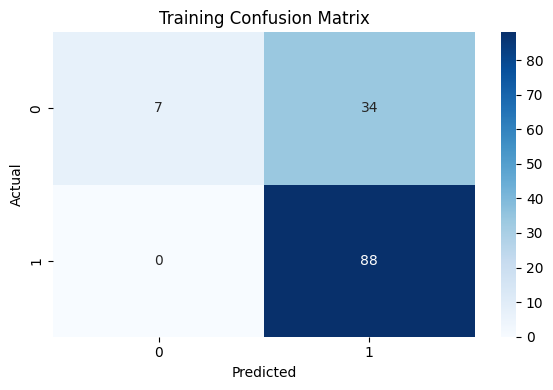


Validation Accuracy: 0.74
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.76      0.97      0.85        33

    accuracy                           0.74        43
   macro avg       0.38      0.48      0.43        43
weighted avg       0.58      0.74      0.65        43



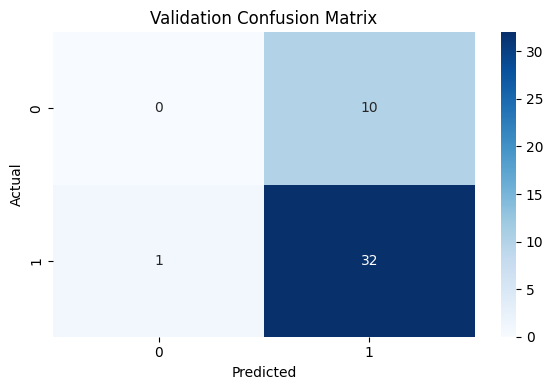


Testing Accuracy: 0.59
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.06      0.10        18
           1       0.60      0.96      0.74        26

    accuracy                           0.59        44
   macro avg       0.55      0.51      0.42        44
weighted avg       0.56      0.59      0.48        44



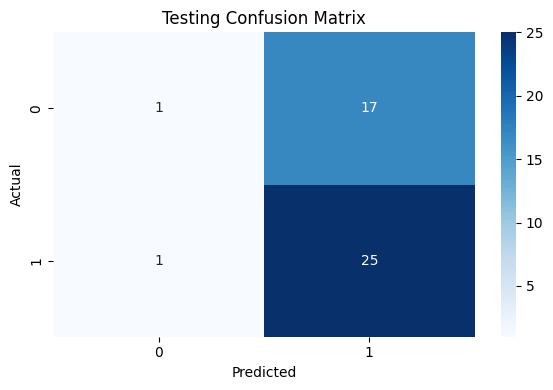

In [52]:

from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-Nearest Neighbors classifier
model = KNeighborsClassifier()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)

# Function to evaluate and plot
def evaluate_model(X, y, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{dataset_name} Accuracy: {acc:.2f}")
    print(f"{dataset_name} Classification Report:\n{classification_report(y, y_pred)}")

    conf_matrix = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Evaluate on all three sets
evaluate_model(X_train_scaled, y_train, "Training")
evaluate_model(X_val_scaled, y_val, "Validation")
evaluate_model(X_test_scaled, y_test, "Testing")




Training Accuracy: 1.00
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        88

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129



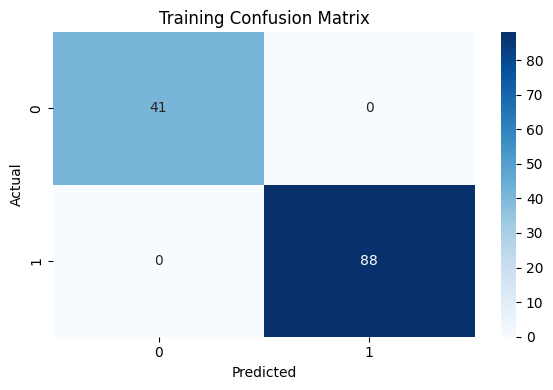


Validation Accuracy: 0.81
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.20      0.33        10
           1       0.80      1.00      0.89        33

    accuracy                           0.81        43
   macro avg       0.90      0.60      0.61        43
weighted avg       0.85      0.81      0.76        43



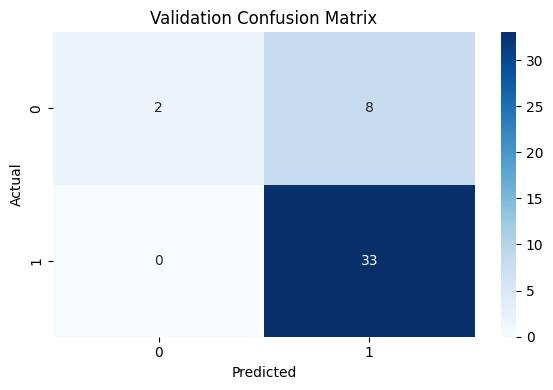


Testing Accuracy: 0.59
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.59      1.00      0.74        26

    accuracy                           0.59        44
   macro avg       0.30      0.50      0.37        44
weighted avg       0.35      0.59      0.44        44



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


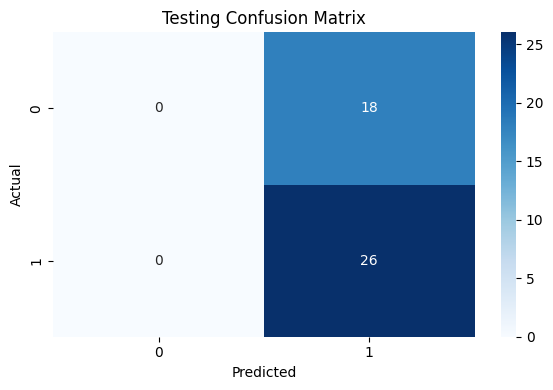

In [53]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier()
model.fit(X_train_scaled, y_train)

# Function to evaluate and plot
def evaluate_model(X, y, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{dataset_name} Accuracy: {acc:.2f}")
    print(f"{dataset_name} Classification Report:\n{classification_report(y, y_pred)}")

    conf_matrix = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Evaluate on all three sets
evaluate_model(X_train_scaled, y_train, "Training")
evaluate_model(X_val_scaled, y_val, "Validation")
evaluate_model(X_test_scaled, y_test, "Testing")





Training Accuracy: 1.00
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        88

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129



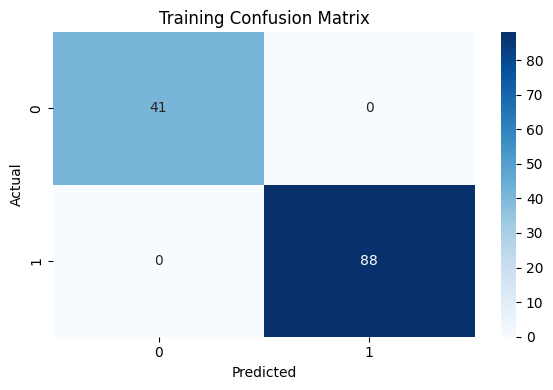


Validation Accuracy: 0.79
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.30      0.40        10
           1       0.82      0.94      0.87        33

    accuracy                           0.79        43
   macro avg       0.71      0.62      0.64        43
weighted avg       0.77      0.79      0.76        43



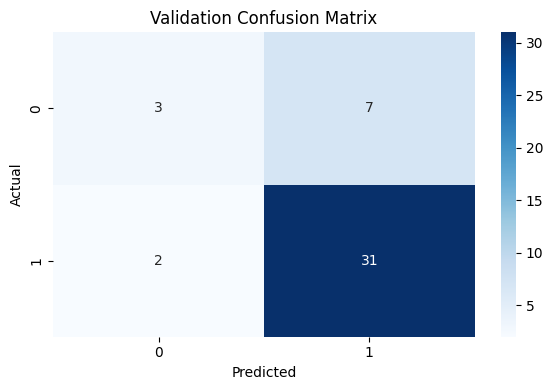


Testing Accuracy: 0.52
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.56      0.88      0.69        26

    accuracy                           0.52        44
   macro avg       0.28      0.44      0.34        44
weighted avg       0.33      0.52      0.41        44



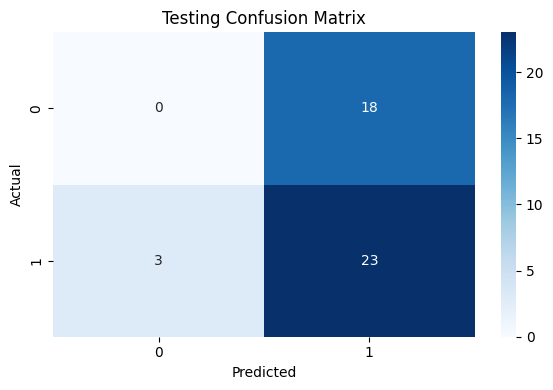

In [54]:

from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = GradientBoostingClassifier()
model.fit(X_train_scaled, y_train)

# Function to evaluate and plot
def evaluate_model(X, y, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{dataset_name} Accuracy: {acc:.2f}")
    print(f"{dataset_name} Classification Report:\n{classification_report(y, y_pred)}")

    conf_matrix = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Evaluate on all three sets
evaluate_model(X_train_scaled, y_train, "Training")
evaluate_model(X_val_scaled, y_val, "Validation")
evaluate_model(X_test_scaled, y_test, "Testing")




Training Accuracy: 1.00
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        88

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129



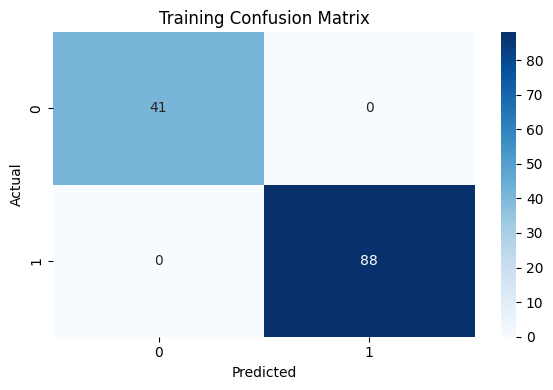


Validation Accuracy: 0.56
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.20      0.17        10
           1       0.73      0.67      0.70        33

    accuracy                           0.56        43
   macro avg       0.44      0.43      0.44        43
weighted avg       0.60      0.56      0.58        43



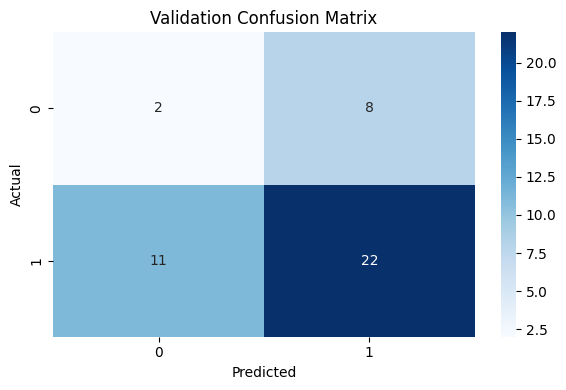


Testing Accuracy: 0.52
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.33      0.36        18
           1       0.59      0.65      0.62        26

    accuracy                           0.52        44
   macro avg       0.49      0.49      0.49        44
weighted avg       0.51      0.52      0.51        44



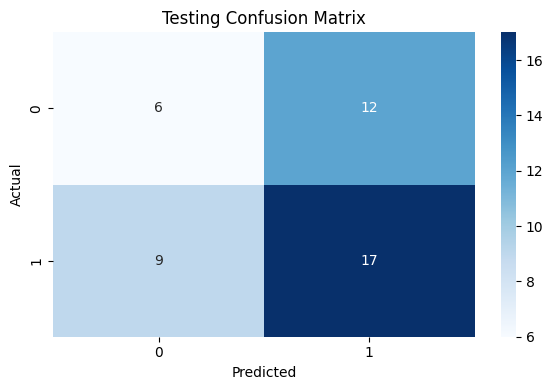

In [55]:

from sklearn.tree import DecisionTreeClassifier
# Initialize the Decision Tree classifier
model = DecisionTreeClassifier()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)

# Function to evaluate and plot
def evaluate_model(X, y, dataset_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{dataset_name} Accuracy: {acc:.2f}")
    print(f"{dataset_name} Classification Report:\n{classification_report(y, y_pred)}")

    conf_matrix = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Evaluate on all three sets
evaluate_model(X_train_scaled, y_train, "Training")
evaluate_model(X_val_scaled, y_val, "Validation")
evaluate_model(X_test_scaled, y_test, "Testing")



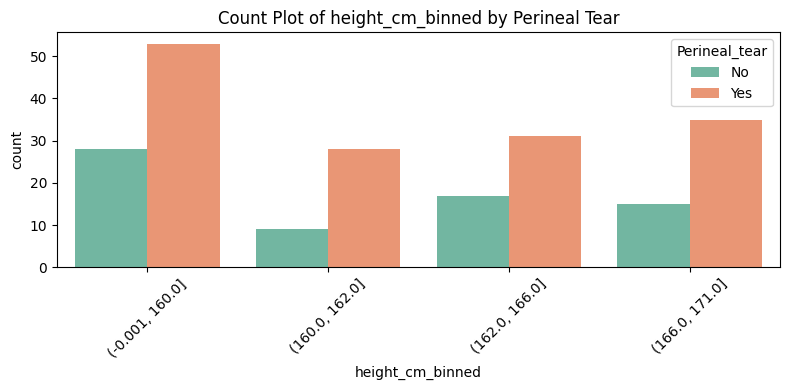

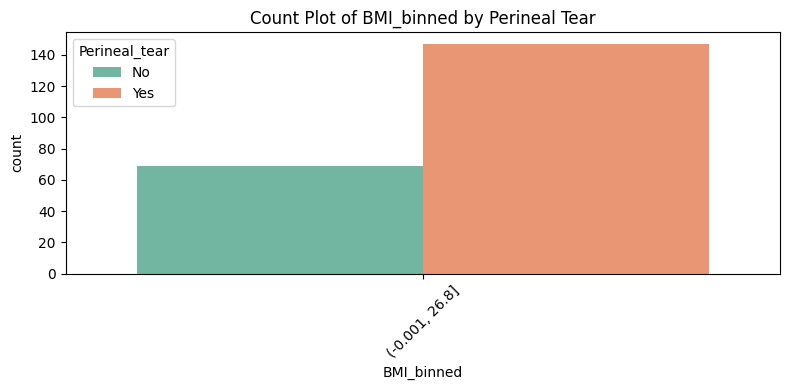

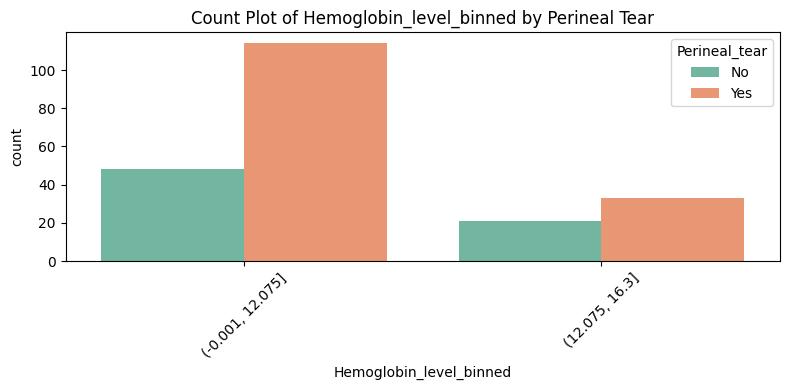

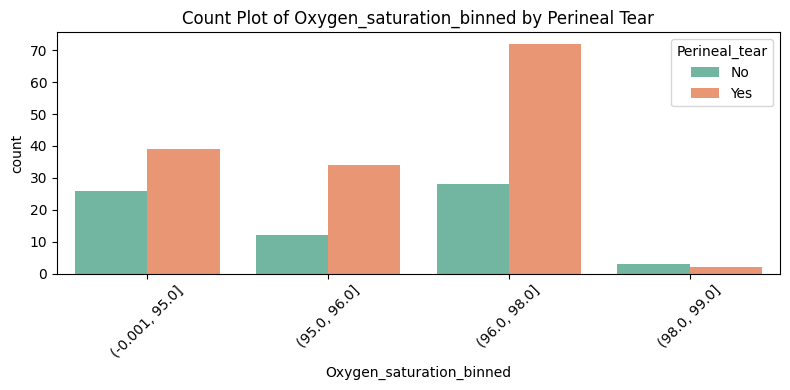

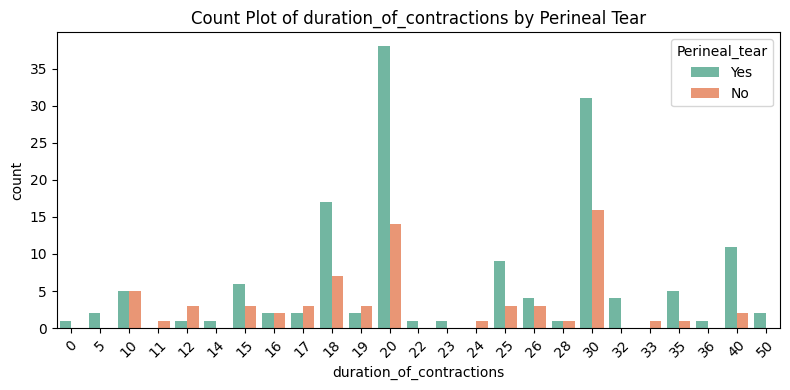

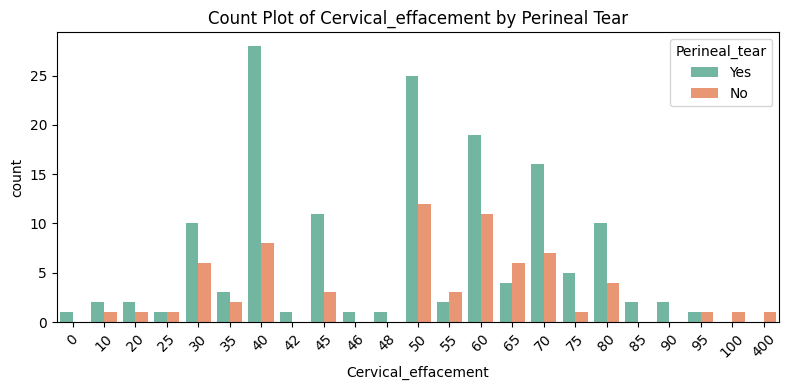

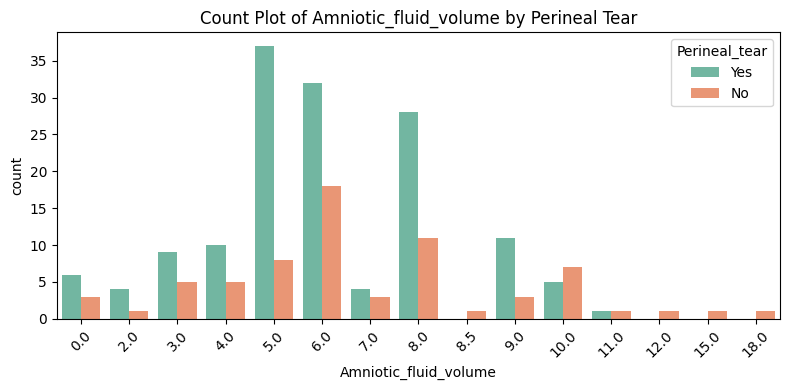

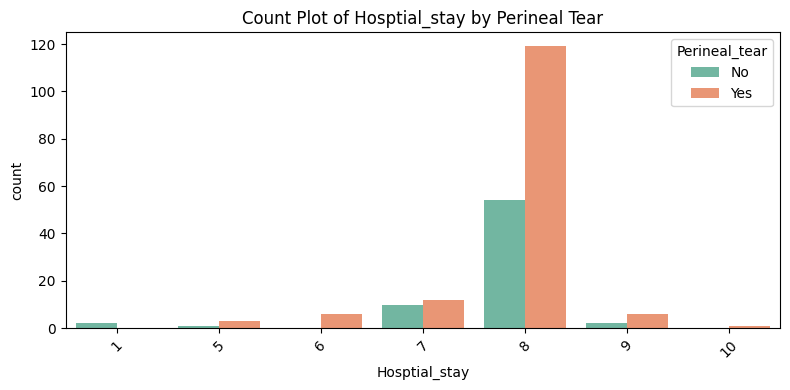

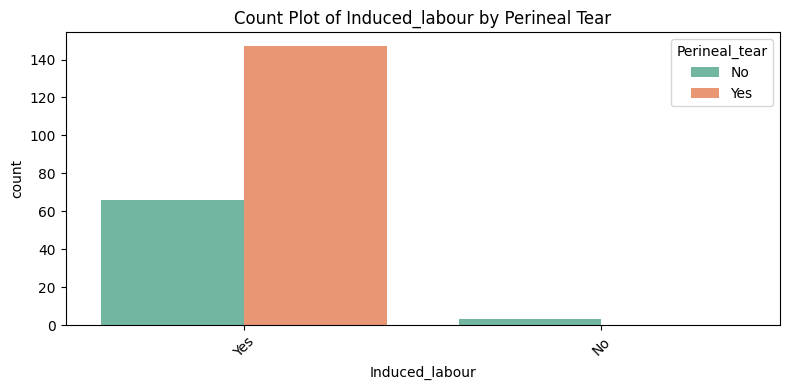

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(file_path)

# Convert target to categorical if needed
if df['Perineal_tear'].dtype != 'object':
    df['Perineal_tear'] = df['Perineal_tear'].astype('category')

# List of variables to plot
variables = [
    'height_cm',
    'BMI',
    'Hemoglobin_level',
    'Oxygen_saturation',
    'duration_of_contractions',
    'Cervical_effacement',
    'Amniotic_fluid_volume',
    'Hosptial_stay',
    'Induced_labour'
]

# Bin continuous variables for count plot
for col in ['height_cm', 'BMI', 'Hemoglobin_level', 'Oxygen_saturation']:
    df[col + '_binned'] = pd.qcut(df[col], q=4, duplicates='drop')  # quartile binning

# Update variable list with binned names where necessary
plot_vars = [
    'height_cm_binned',
    'BMI_binned',
    'Hemoglobin_level_binned',
    'Oxygen_saturation_binned',
    'duration_of_contractions',
    'Cervical_effacement',
    'Amniotic_fluid_volume',
    'Hosptial_stay',
    'Induced_labour'
]

# Plot
for var in plot_vars:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=var, hue='Perineal_tear', palette='Set2')
    plt.title(f'Count Plot of {var} by Perineal Tear')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


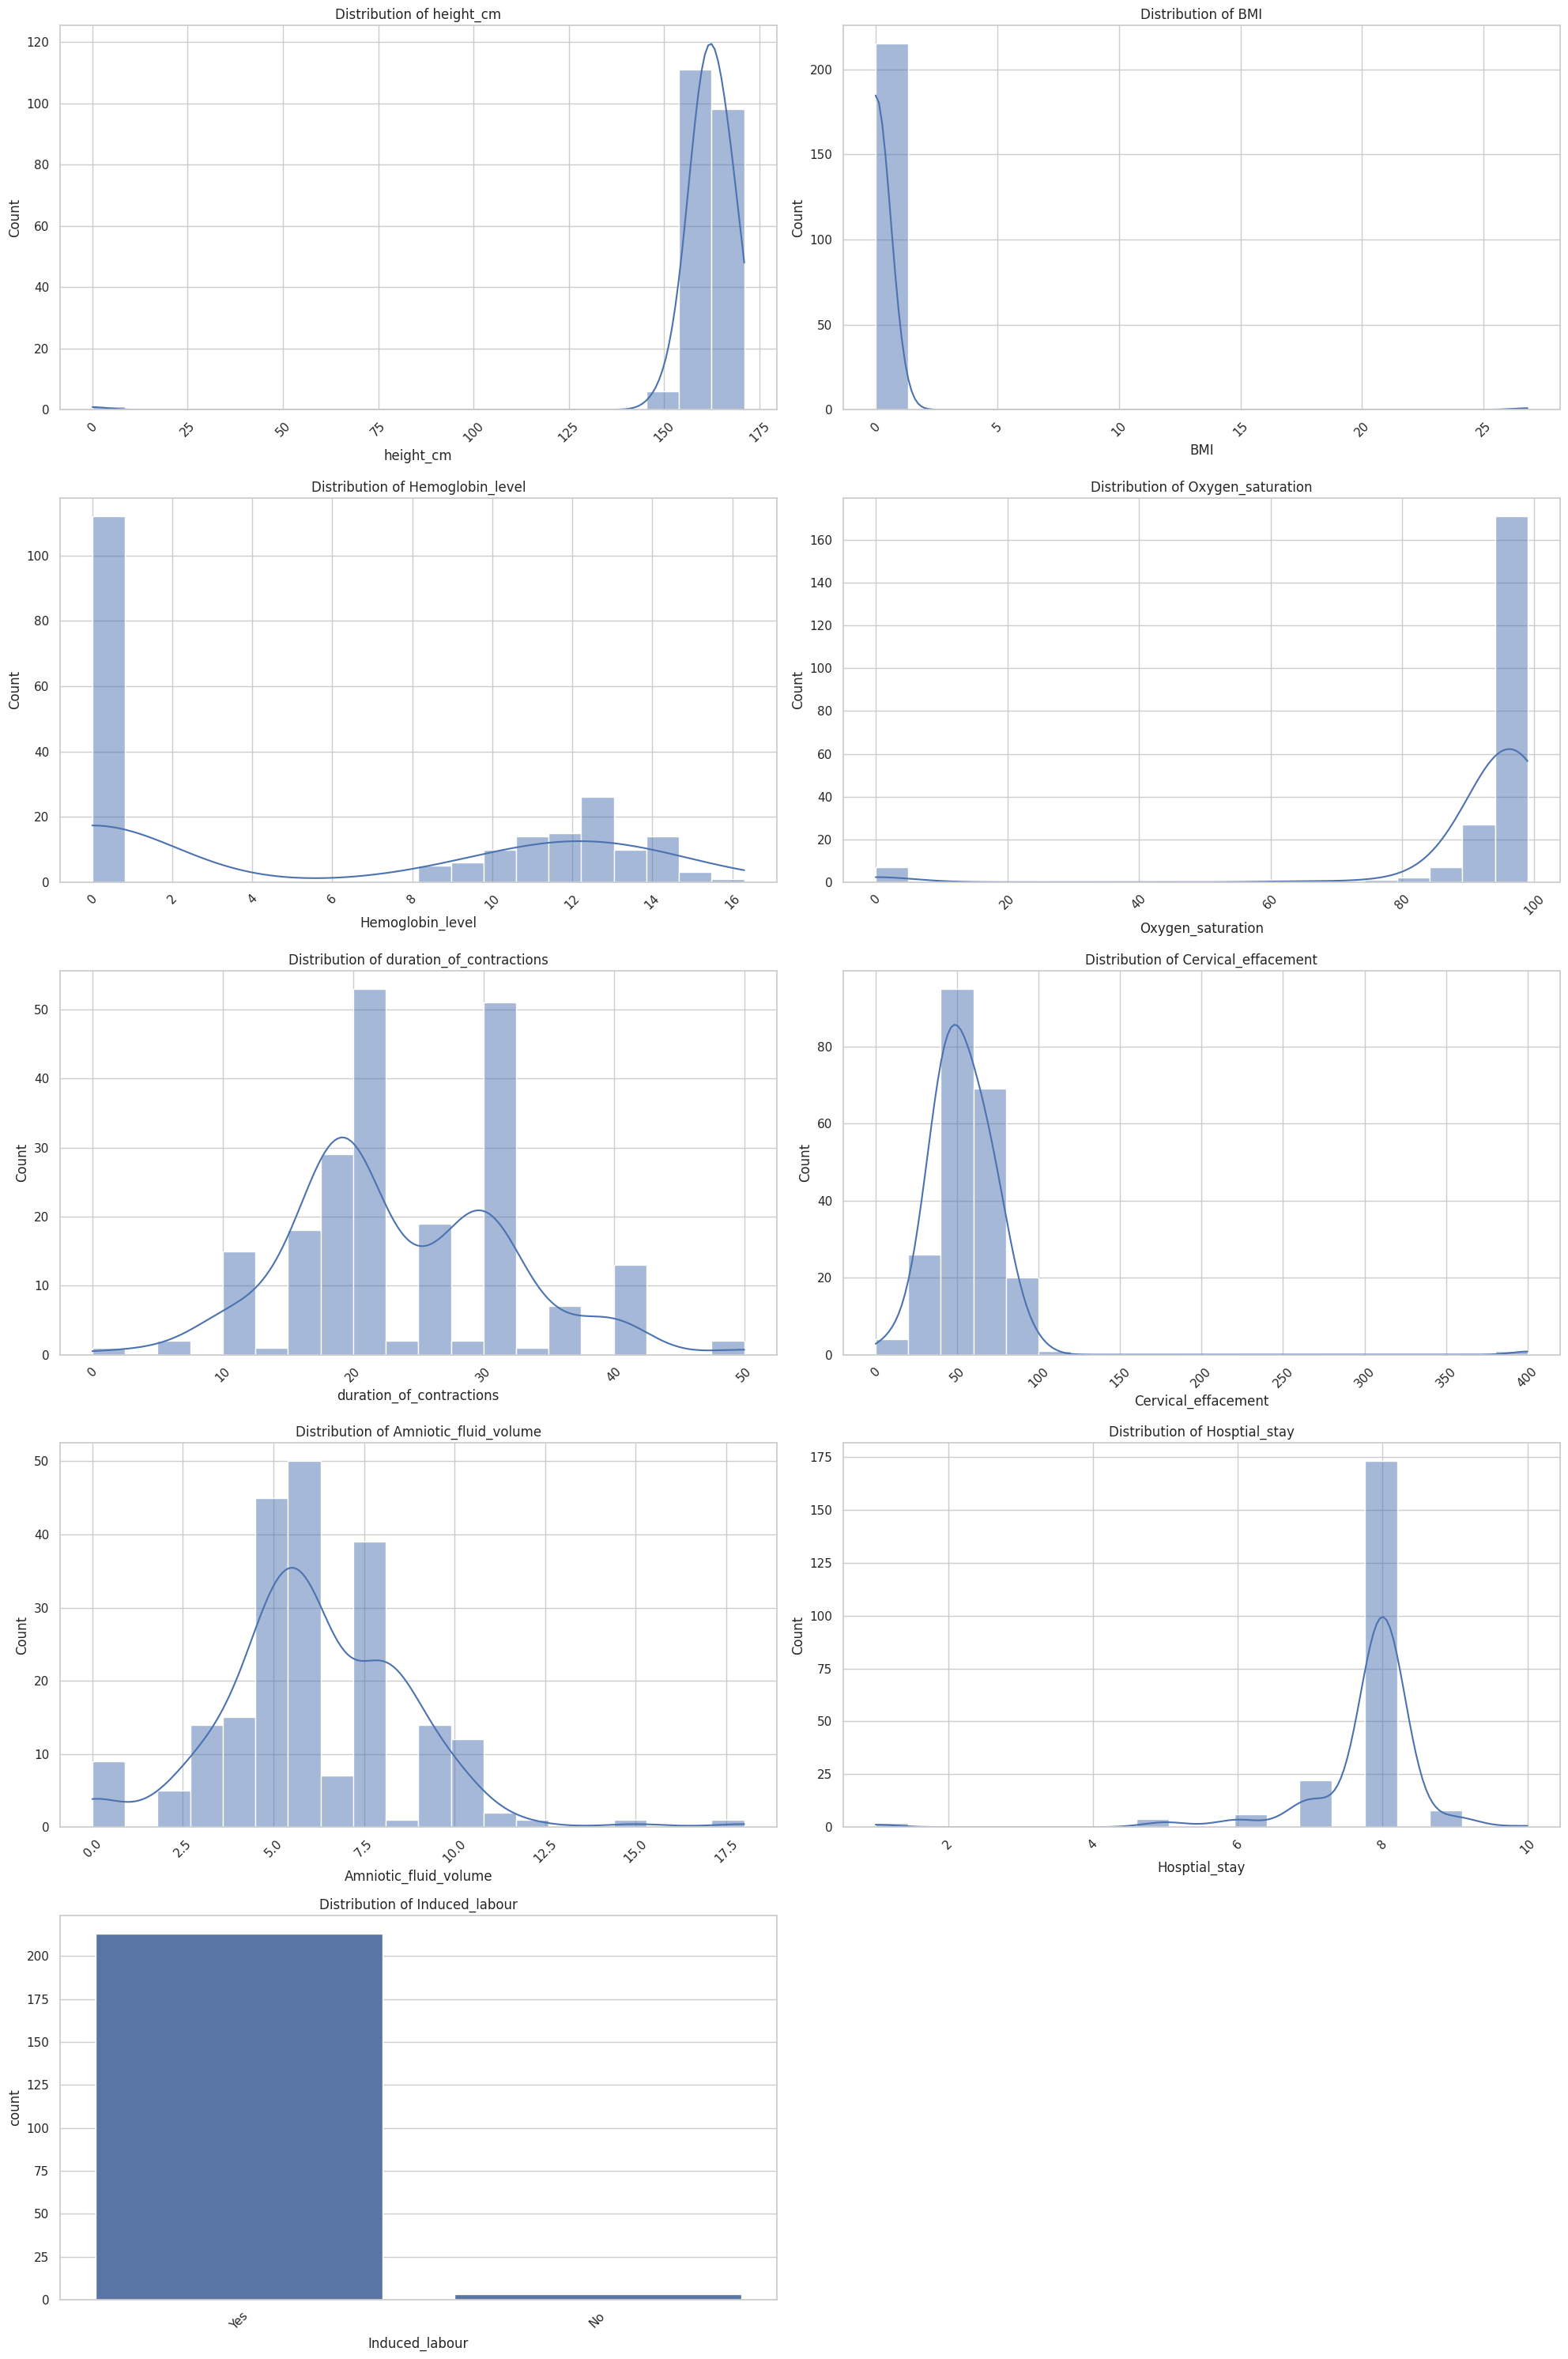

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
dataset = pd.read_csv(file_path)

# List of variables to visualize
variables = [
    'height_cm',
    'BMI',
    'Hemoglobin_level',
    'Oxygen_saturation',
    'duration_of_contractions',
    'Cervical_effacement',
    'Amniotic_fluid_volume',
    'Hosptial_stay',
    'Induced_labour'
]

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(20, 30))

# Plot each variable
for i, var in enumerate(variables):
    plt.subplot(5, 2, i+1)  # Adjust grid size based on number of variables
    if pd.api.types.is_numeric_dtype(dataset[var]):
        # Use histogram for continuous/numeric variables
        sns.histplot(data=dataset, x=var, kde=True, bins=20)
    else:
        # Use countplot for categorical variables
        sns.countplot(data=dataset, x=var)
    plt.title(f'Distribution of {var}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [58]:
pip install shap

fitting models

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,          # number of trees
    max_depth=5,               # limit depth to reduce complexity
    min_samples_leaf=4,        # each leaf must have at least 4 samples
    max_features='sqrt',       # reduces correlation between trees
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, min_samples_leaf=4, n_jobs=-1,
                       random_state=42)

In [61]:
!pip install catboost
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,           # slow learning to generalize better
    depth=4,                      # shallower trees
    l2_leaf_reg=3,                # helps generalization
    early_stopping_rounds=20,     # stops if overfitting starts
    verbose=0,
    random_seed=42
)
catboost_model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)


In [62]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,           # total trees
    learning_rate=0.05,         # low learning rate for better generalization
    max_depth=3,                # limits complexity
    min_samples_leaf=5,         # avoid learning from noise
    subsample=0.8,              # stochastic gradient boosting
    random_state=42
)
gb_model.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=5,
                           n_estimators=200, random_state=42, subsample=0.8)

In [63]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,                 # shallow trees generalize better
    min_samples_leaf=5,         # more samples per leaf
    min_samples_split=10,       # minimum samples to split an internal node
    max_features='sqrt',        # reduce overfitting by random feature selection
    random_state=42
)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, max_features='sqrt', min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

class balancing

In [64]:
pip install imbalanced-learn catboost


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report


In [66]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_resampled, y_resampled)
print("Logistic Regression:\n", classification_report(y_test, lr.predict(X_test)))

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_resampled, y_resampled)
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))

# Note: GradientBoostingClassifier does not support class_weight directly
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_resampled, y_resampled)
print("Gradient Boosting:\n", classification_report(y_test, gb.predict(X_test)))

cat = CatBoostClassifier(verbose=0, auto_class_weights='Balanced')
cat.fit(X_resampled, y_resampled)
print("CatBoost:\n", classification_report(y_test, cat.predict(X_test)))

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_resampled, y_resampled)
print("Decision Tree:\n", classification_report(y_test, dt.predict(X_test)))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
               precision    recall  f1-score   support

           0       0.50      0.21      0.30        14
           1       0.71      0.90      0.79        30

    accuracy                           0.68        44
   macro avg       0.61      0.56      0.55        44
weighted avg       0.64      0.68      0.64        44

Random Forest:
               precision    recall  f1-score   support

           0       1.00      0.21      0.35        14
           1       0.73      1.00      0.85        30

    accuracy                           0.75        44
   macro avg       0.87      0.61      0.60        44
weighted avg       0.82      0.75      0.69        44

Gradient Boosting:
               precision    recall  f1-score   support

           0       0.62      0.36      0.45        14
           1       0.75      0.90      0.82        30

    accuracy                           0.73        44
   macro avg       0.69      0.63      0.64        44
weighted avg    

handling complexity without regulation

In [67]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

gb = GradientBoostingClassifier(
    n_estimators=100,         # fewer trees
    learning_rate=0.05,       # conservative learning
    max_depth=3,              # shallow trees
    min_samples_split=5,      # control splitting
    subsample=0.8,            # add randomness
    random_state=42
)

gb.fit(X_train, y_train)
print("Gradient Boosting:\n", classification_report(y_test, gb.predict(X_test)))


Gradient Boosting:
               precision    recall  f1-score   support

           0       0.50      0.07      0.12        14
           1       0.69      0.97      0.81        30

    accuracy                           0.68        44
   macro avg       0.60      0.52      0.47        44
weighted avg       0.63      0.68      0.59        44



In [68]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=100,           # number of trees
    learning_rate=0.05,       # conservative step
    depth=4,                  # tree depth
    min_data_in_leaf=10,      # control overfitting
    subsample=0.8,            # reduce variance
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)
print("CatBoost:\n", classification_report(y_test, cat.predict(X_test)))


CatBoost:
               precision    recall  f1-score   support

           0       1.00      0.07      0.13        14
           1       0.70      1.00      0.82        30

    accuracy                           0.70        44
   macro avg       0.85      0.54      0.48        44
weighted avg       0.79      0.70      0.60        44



In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,         # fewer trees
    max_depth=5,              # shallow trees
    min_samples_split=10,     # prevent over-splitting
    max_features='sqrt',      # reduce correlation
    bootstrap=True,           # subsampling
    random_state=42
)

rf.fit(X_train, y_train)
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))


Random Forest:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.68      1.00      0.81        30

    accuracy                           0.68        44
   macro avg       0.34      0.50      0.41        44
weighted avg       0.46      0.68      0.55        44



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


shap application

In [85]:
pip install shap catboost scikit-learn matplotlib


In [73]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# For better visualization in notebooks
shap.initjs()
# STEP 1: Load your dataset
dataset = pd.read_csv(file_path)  # Replace with your actual file path
X = dataset.drop('Perineal_tear', axis=1)
y = dataset['Perineal_tear']

# Handle categorical features if any (you may already have this)
X = pd.get_dummies(X)
if y.dtype == 'object':
    y = y.astype('category').cat.codes

# STEP 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



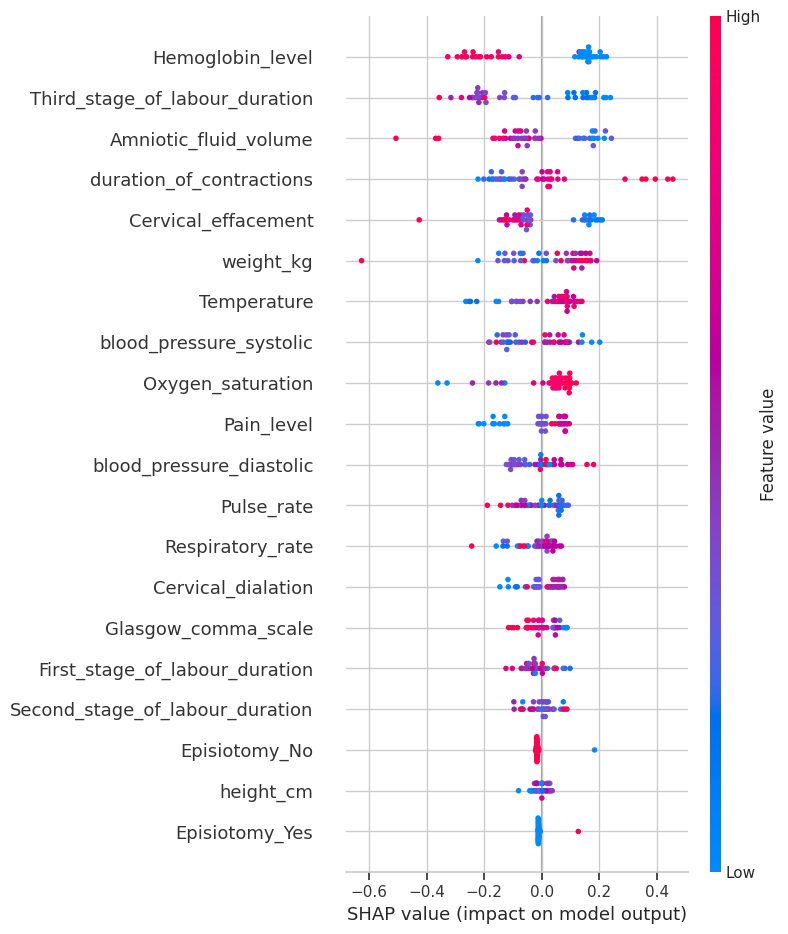

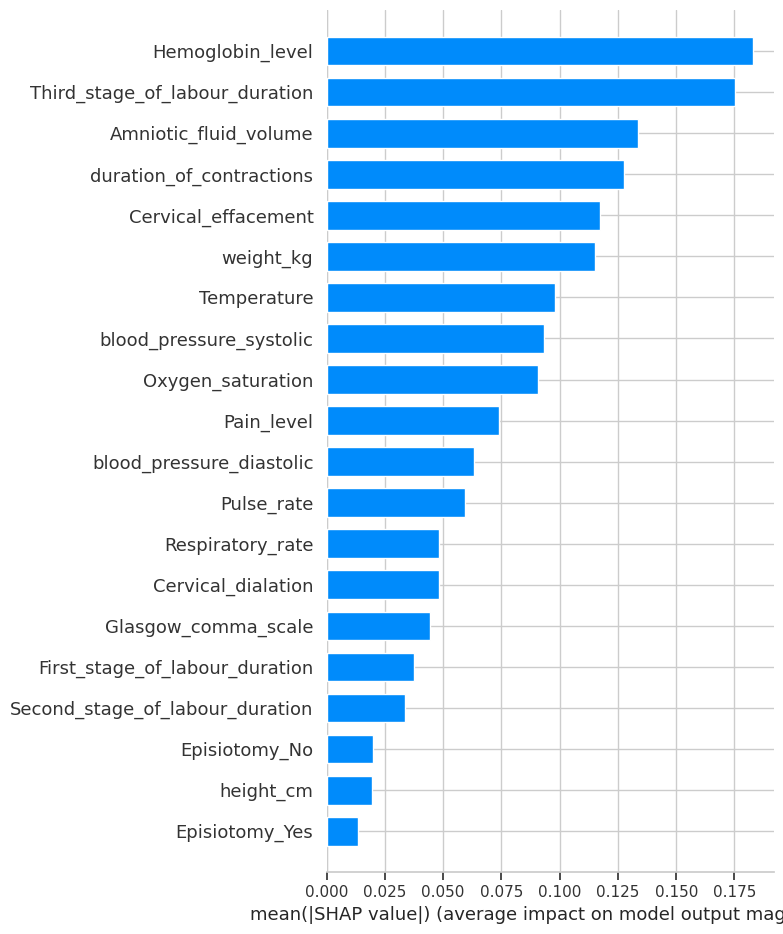

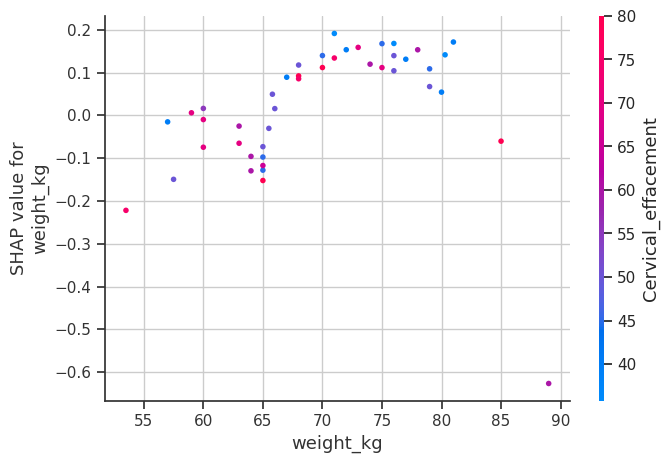

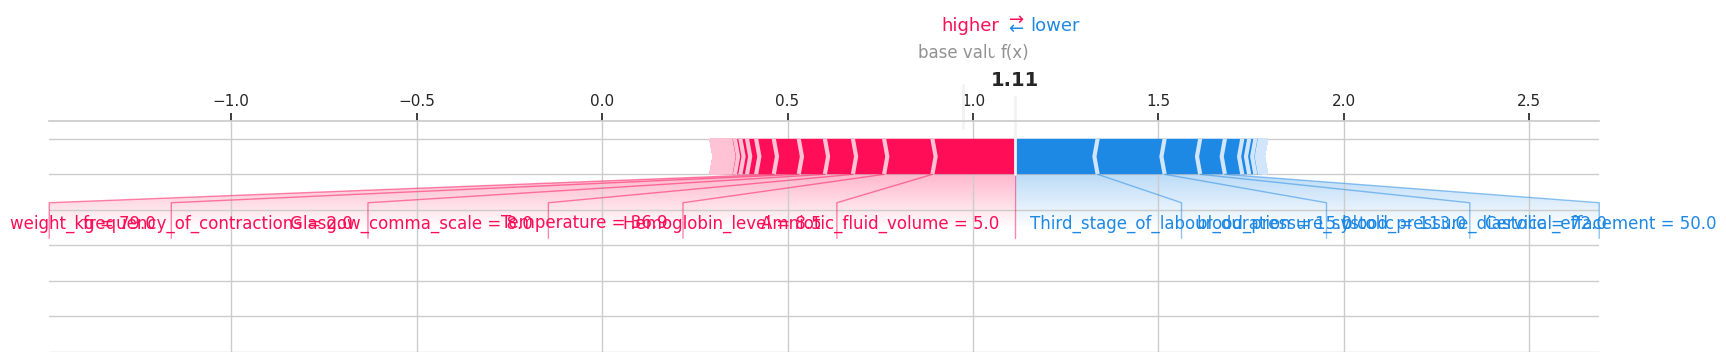

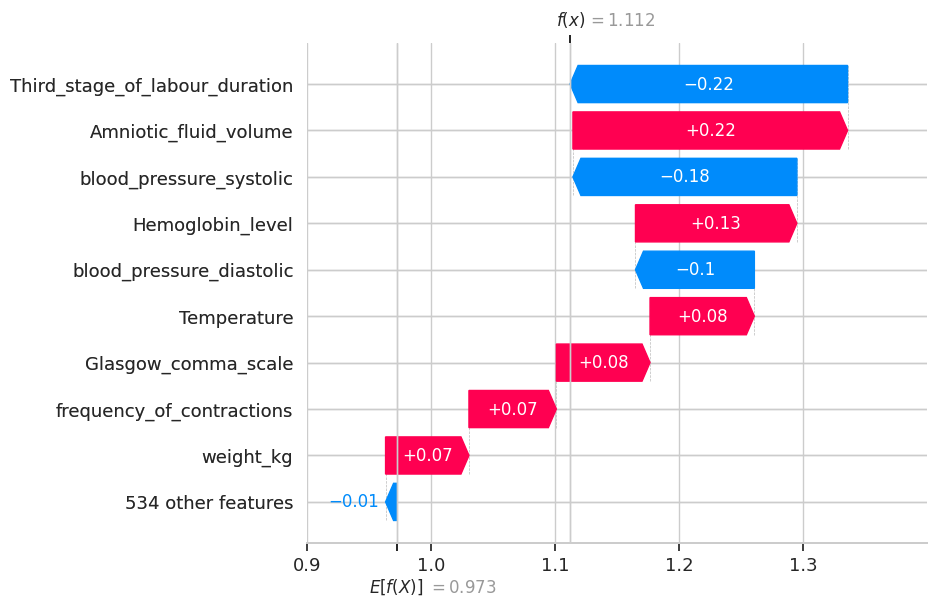

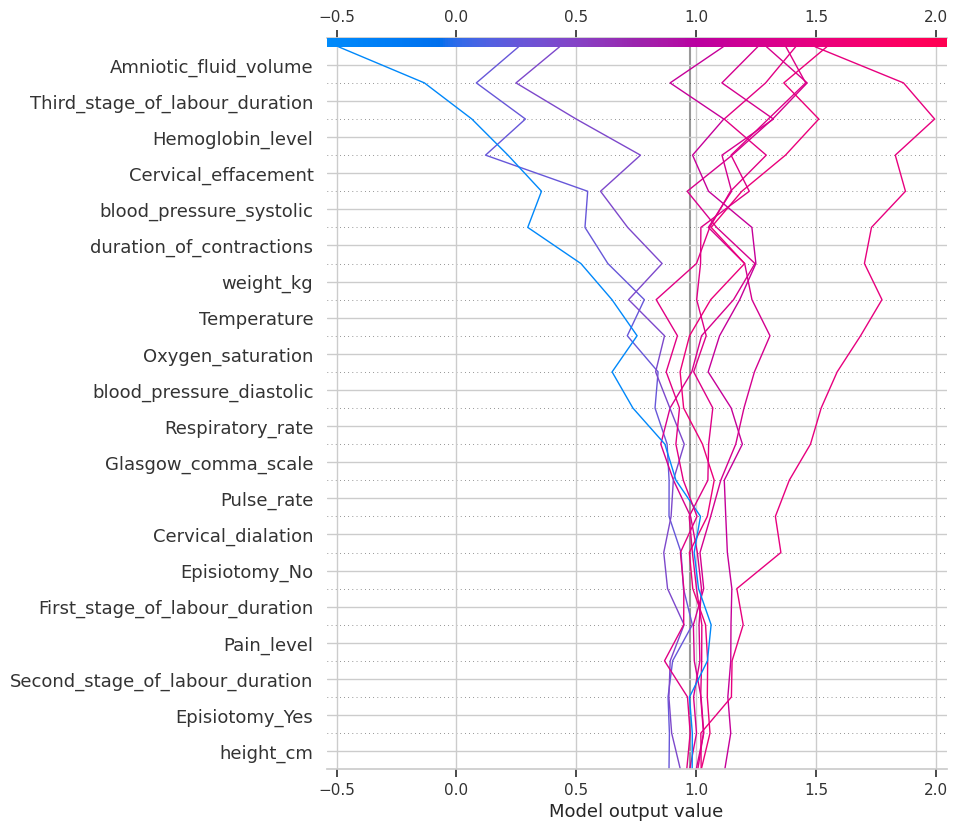

In [74]:
# Train CatBoost
model_cb = CatBoostClassifier(verbose=0, random_seed=42)
model_cb.fit(X_train, y_train)

explainer_cb = shap.TreeExplainer(model_cb)
shap_values_cb = explainer_cb.shap_values(X_test)
feature_name = X_test.columns[0]

shap.summary_plot(shap_values_cb, X_test, plot_type="dot", show=True)
shap.summary_plot(shap_values_cb, X_test, plot_type="bar", show=True)
shap.dependence_plot(feature_name, shap_values_cb, X_test, show=True)
shap.force_plot(explainer_cb.expected_value, shap_values_cb[0,:], X_test.iloc[0,:], matplotlib=True, show=True)
shap.plots._waterfall.waterfall_legacy(explainer_cb.expected_value, shap_values_cb[0,:], feature_names=X_test.columns, max_display=10)
shap.decision_plot(explainer_cb.expected_value, shap_values_cb[:10], X_test.iloc[:10], show=True)




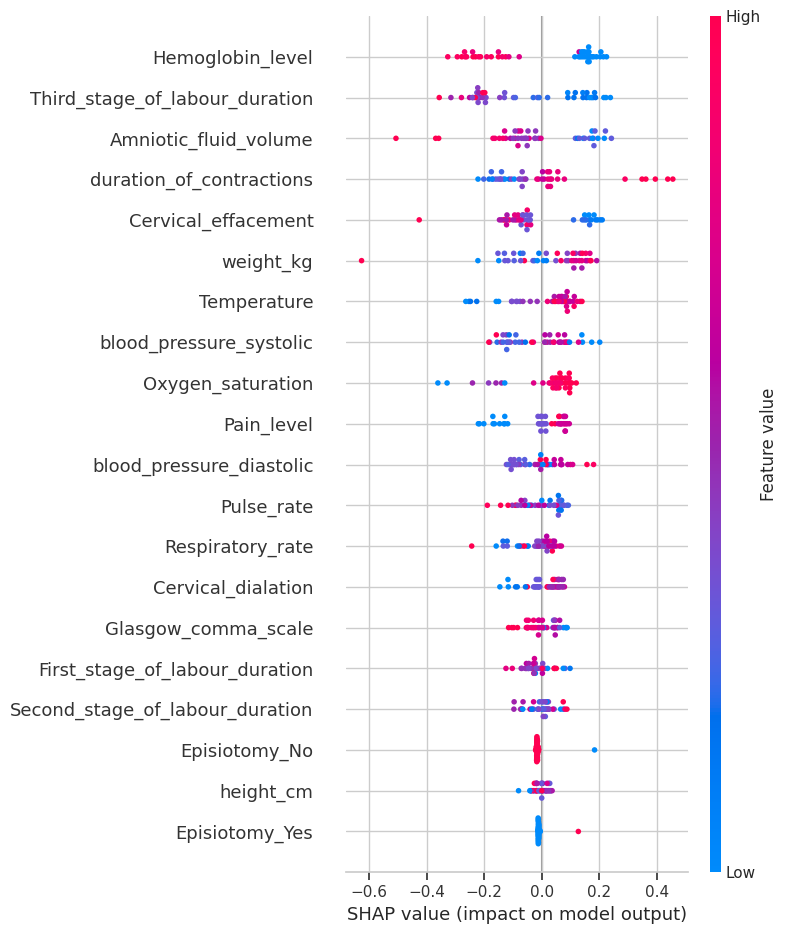

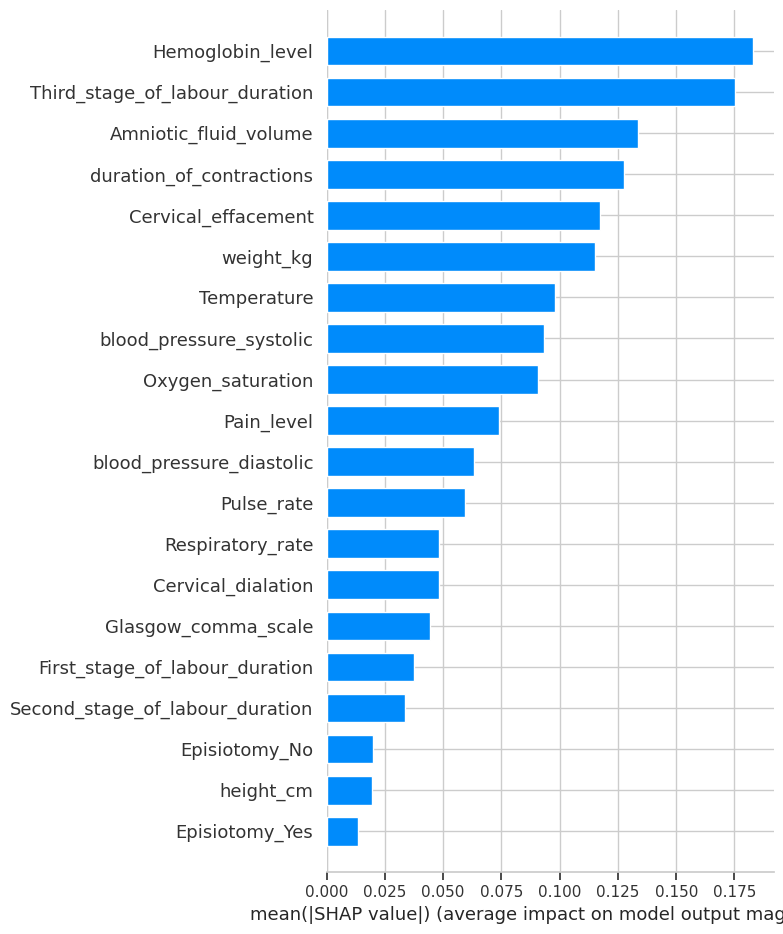

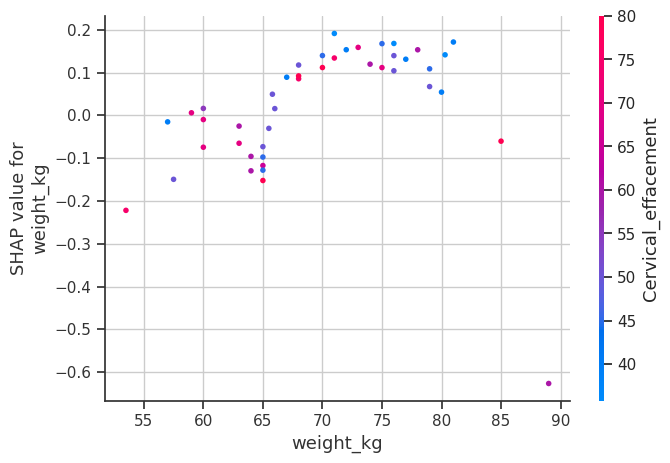

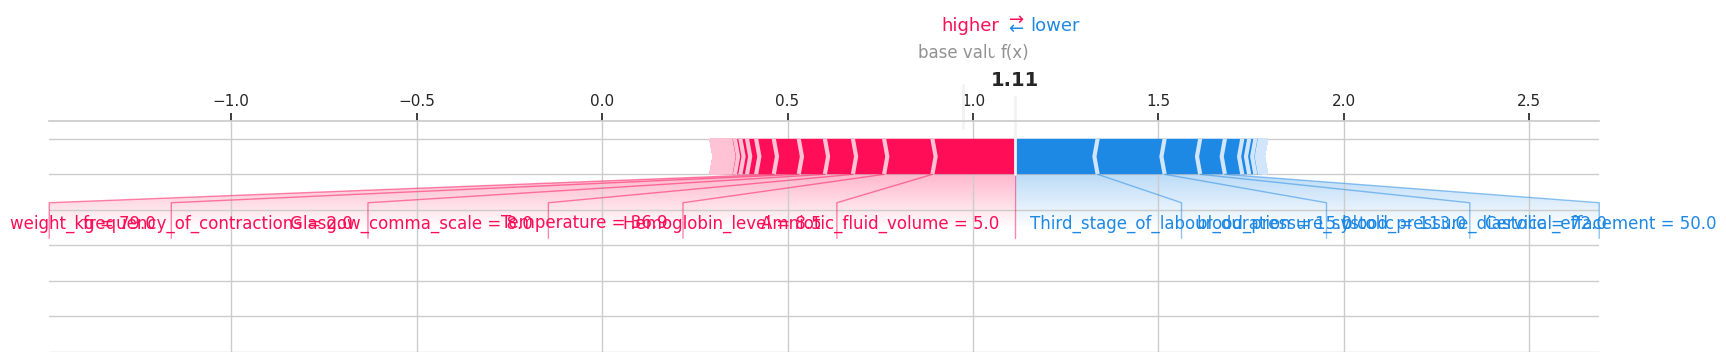

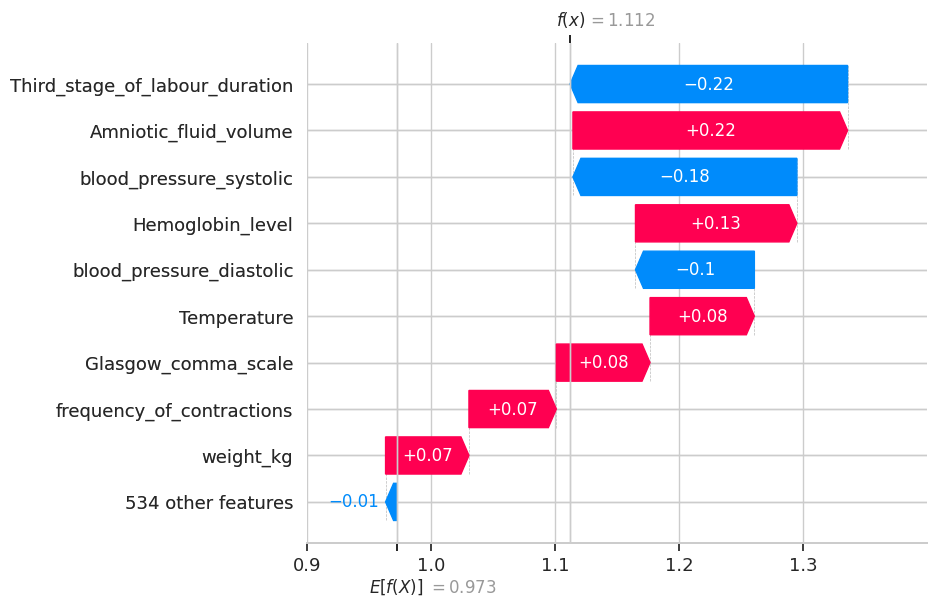

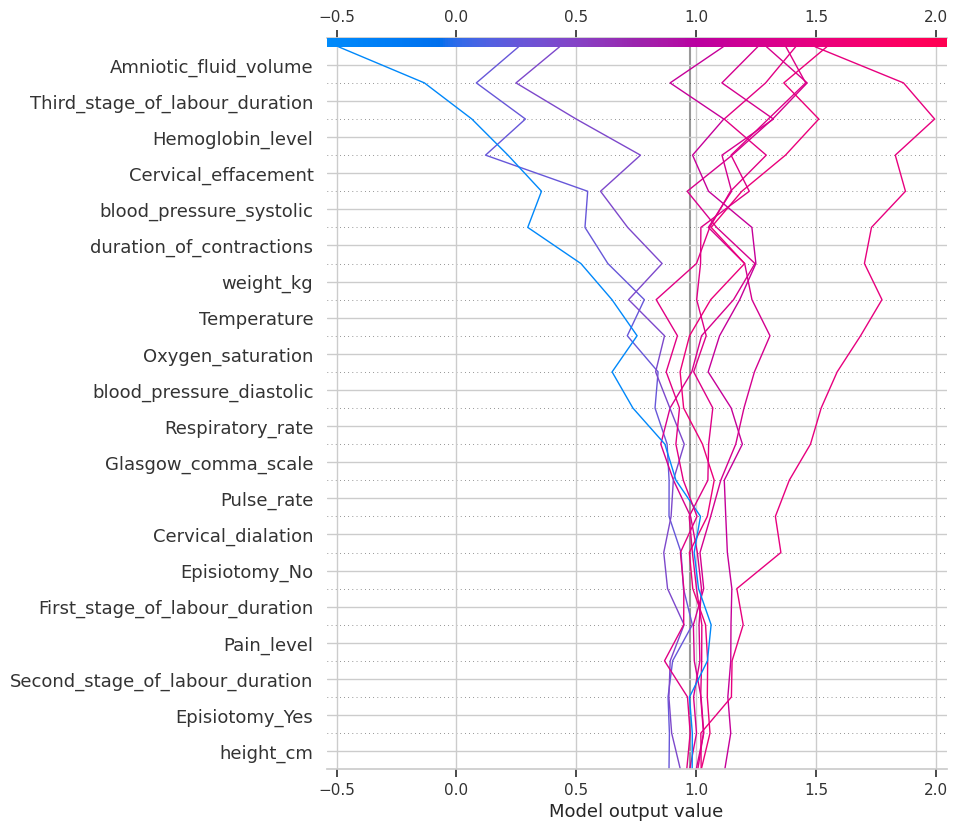

In [81]:

# Train random forest
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

# Create SHAP explainer (TreeExplainer works well with CatBoost)
explainer_rf = shap.TreeExplainer(model_rf)
shap_values_rf = explainer_rf.shap_values(X_test)[1]
feature_name = X_test.columns[0]

# Summary plot
shap.summary_plot(shap_values_cb, X_test, plot_type="dot", show=True)
shap.summary_plot(shap_values_cb, X_test, plot_type="bar", show=True)
shap.dependence_plot(feature_name, shap_values_cb, X_test, show=True)
shap.force_plot(explainer_cb.expected_value, shap_values_cb[0,:], X_test.iloc[0,:], matplotlib=True, show=True)
shap.plots._waterfall.waterfall_legacy(explainer_cb.expected_value, shap_values_cb[0,:], feature_names=X_test.columns, max_display=10)
shap.decision_plot(explainer_cb.expected_value, shap_values_cb[:10], X_test.iloc[:10], show=True)

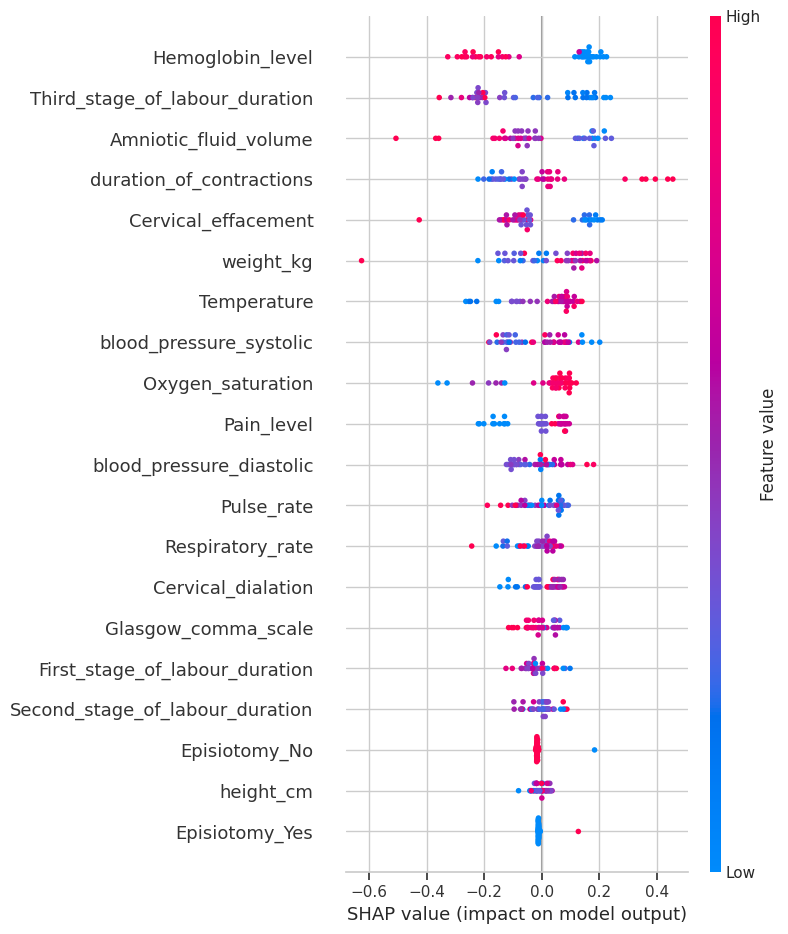

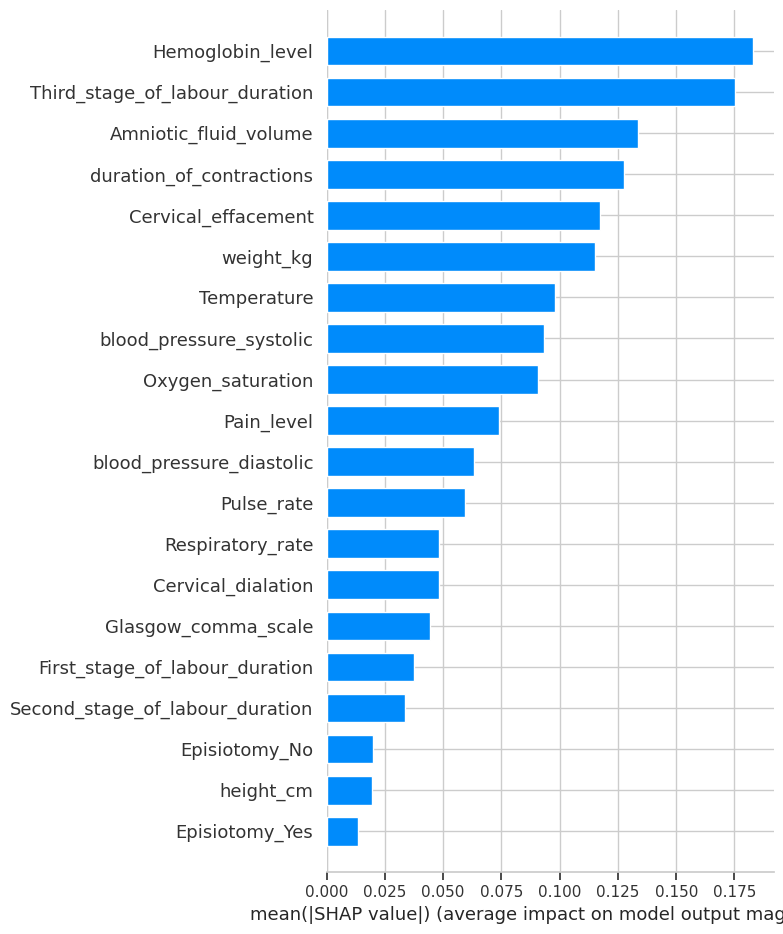

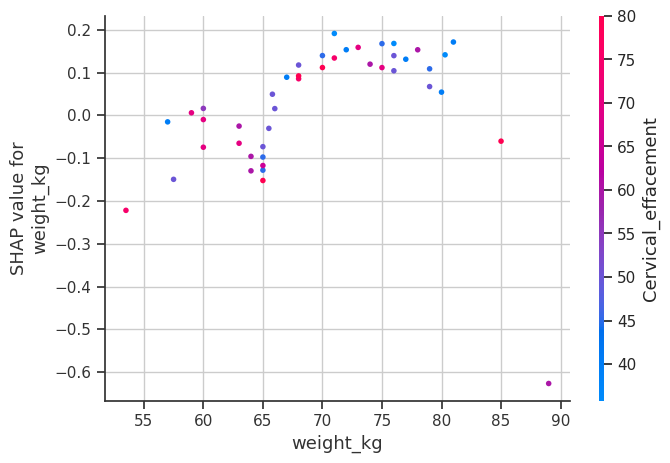

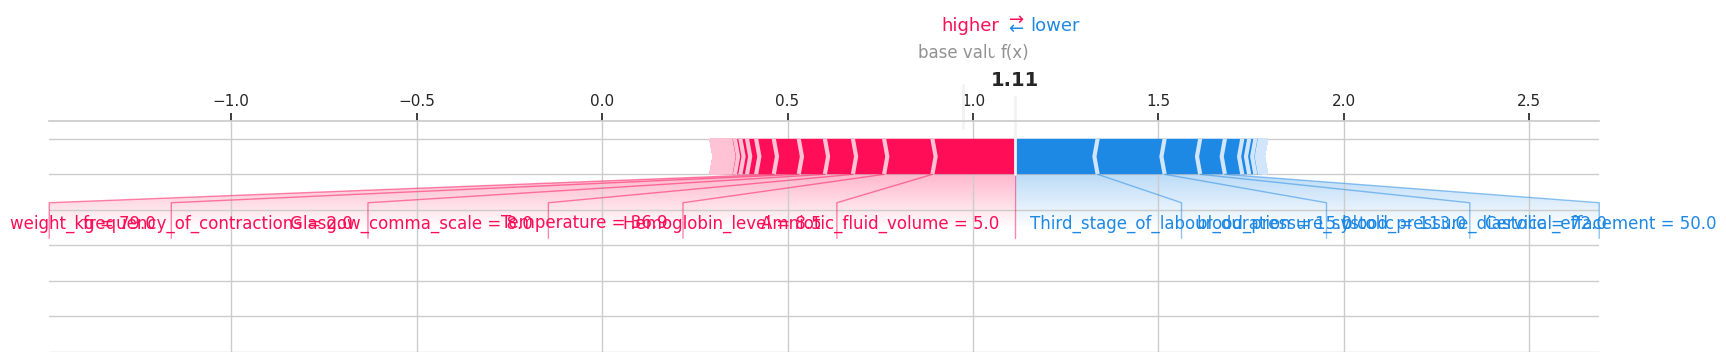

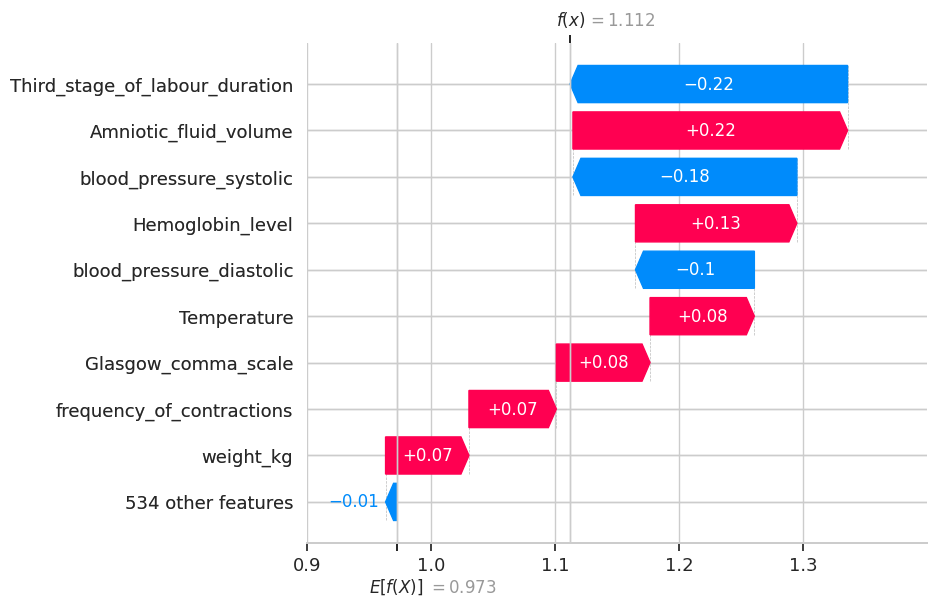

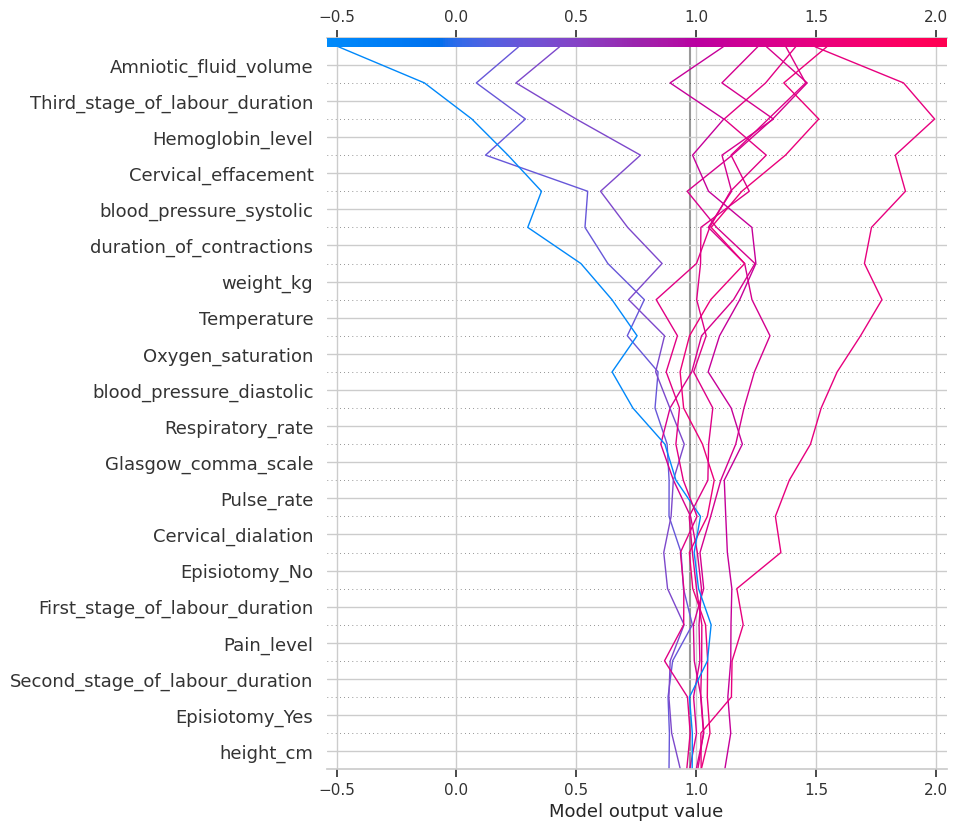

In [82]:

# Train GradientBoostingClassifier
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train, y_train)

# Create SHAP explainer (TreeExplainer works well with CatBoost)
explainer_gb = shap.TreeExplainer(model_gb)
shap_values_gb = explainer_gb.shap_values(X_test)
feature_name = X_test.columns[0]

# Summary plot
shap.summary_plot(shap_values_cb, X_test, plot_type="dot", show=True)
shap.summary_plot(shap_values_cb, X_test, plot_type="bar", show=True)
shap.dependence_plot(feature_name, shap_values_cb, X_test, show=True)
shap.force_plot(explainer_cb.expected_value, shap_values_cb[0,:], X_test.iloc[0,:], matplotlib=True, show=True)
shap.plots._waterfall.waterfall_legacy(explainer_cb.expected_value, shap_values_cb[0,:], feature_names=X_test.columns, max_display=10)
shap.decision_plot(explainer_cb.expected_value, shap_values_cb[:10], X_test.iloc[:10], show=True)